# 05 - Sales Forecasting Model V2

Notebook này xây dựng pipeline dự báo doanh thu và giá vốn cho file nộp `submission.csv`.

Bài toán không chỉ là train một model rồi predict. Vì test set thật của ban tổ chức không công bố, notebook cần mô phỏng tình huống tương lai càng giống thật càng tốt:

- Dữ liệu lịch sử có `Revenue` và `COGS` đến cuối năm 2022.
- File `sample_submission.csv` chỉ cho biết các ngày cần dự đoán trong giai đoạn 2023-2024.
- Mục tiêu cuối cùng là tạo `outputs/submission.csv` đúng format gồm `Date`, `Revenue`, `COGS`.

Notebook có hai tầng đánh giá:

- Tầng 1: validation một năm 2022 để kiểm tra nhanh model, feature và ensemble.
- Tầng 2: rolling validation nhiều năm 2019-2022 để chọn cách dự báo ổn định hơn trước khi nộp.

Một số thuật ngữ chính:

- `Leakage`: dùng nhầm thông tin tương lai trong lúc train hoặc validation. Nếu xảy ra, điểm validation sẽ đẹp giả nhưng leaderboard thật thường tệ.
- `Holdout`: một giai đoạn lịch sử được giữ lại làm validation, ví dụ năm 2022.
- `Rolling CV`: đánh giá nhiều lần theo thời gian, ví dụ train đến 2018 dự báo 2019, train đến 2019 dự báo 2020.
- `Recursive forecast`: dự báo từng ngày, rồi dùng prediction của ngày trước để tạo lag/rolling cho ngày sau.
- `Direct seasonal`: dự báo trực tiếp từ pattern mùa vụ lịch sử, không phụ thuộc prediction ngày trước nên ít bị tích lũy lỗi.
- `Anchor`: baseline mùa vụ dùng để kéo prediction về mức hợp lý, giúp forecast dài hạn ít drift.
- `Monthly calibration`: điều chỉnh prediction theo từng tháng để monthly mean không lệch quá xa kỳ vọng lịch sử.


## Section 0 - Setup

Cell code bên dưới import các thư viện và helper function cần dùng trong notebook.

Vai trò của cell này:

- Thêm `../src/utils` vào `sys.path` để notebook gọi được code trong repo.
- Import model params, metric, ensemble helper, submission helper.
- Import các hàm forecasting quan trọng như `make_supervised_frame`, `recursive_forecast`, `seasonal_growth_baseline`.
- In version của LightGBM/XGBoost và kiểm tra CatBoost có khả dụng không.

Nếu cell này lỗi, các section phía sau sẽ không chạy được. Đây là cell nền tảng của toàn bộ notebook.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src/utils"))
import models
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb

from models import (
    LGBM_PARAMS, XGB_PARAMS, CATBOOST_PARAMS, CatBoostRegressor,
    compute_metrics, TimeSeriesCV,
    predict_cogs, print_cv_table,
    train_final_lgbm, train_final_xgb, train_final_catboost,
)
from utils import (
    setup_plot_style, build_submission, run_submission_checks,
    plot_actual_vs_predicted, plot_feature_importance, print_model_card,
)
from forecasting_v2 import (
    build_promo_profile, build_traffic_profile, build_inventory_profile,
    make_supervised_frame, impute_feature_frame, recursive_forecast, seasonal_growth_baseline,
    calibrate_monthly_predictions, seasonal_window_baseline,
    build_business_daily_table, build_business_profile,
    build_component_shape_profile, forecast_component_shape, blend_with_normalized_shape,
    forecast_cogs_ratio_model,
    RECURSIVE_BASELINE_BLEND, RECURSIVE_EWM_ALPHA,
)

RANDOM_SEED = 42
RECURSIVE_BLEND_WEIGHT = RECURSIVE_BASELINE_BLEND
RECURSIVE_SMOOTH_ALPHA = RECURSIVE_EWM_ALPHA
np.random.seed(RANDOM_SEED)
setup_plot_style()

print("All imports OK")
print(f"   LightGBM: {lgb.__version__}")
print(f"   XGBoost : {xgb.__version__}")
if CatBoostRegressor is not None:
    print("   CatBoost: available")
else:
    print("   CatBoost: not installed (2-model fallback)")
print(f"   Recursive blend weight: {RECURSIVE_BLEND_WEIGHT:.2f}")
print(f"   Recursive smooth alpha: {RECURSIVE_SMOOTH_ALPHA:.2f}")

All imports OK
   LightGBM: 4.6.0
   XGBoost : 3.2.0
   CatBoost: available
   Recursive blend weight: 0.10
   Recursive smooth alpha: 0.85


## Section 1 - Load Data

Cell code bên dưới đọc dữ liệu đầu vào từ thư mục `dataset`.

Các bảng chính:

- `sales.csv`: chứa target lịch sử gồm `Date`, `Revenue`, `COGS`.
- `sample_submission.csv`: chứa danh sách ngày cần dự đoán và format file nộp.
- `promotions.csv`: thông tin campaign khuyến mãi lịch sử.
- `web_traffic.csv`: tín hiệu traffic theo ngày và nguồn truy cập.
- `inventory.csv`: tín hiệu tồn kho, stockout, fill rate.

Điểm quan trọng: `sample_submission.csv` không phải ground truth. Nó chỉ là template để biết số dòng, thứ tự ngày và tên cột cần xuất.


In [2]:
sales      = pd.read_csv("../dataset/sales.csv",             parse_dates=["Date"])
sample_sub = pd.read_csv("../dataset/sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv("../dataset/promotions.csv",        parse_dates=["start_date", "end_date"])
web_traffic= pd.read_csv("../dataset/web_traffic.csv",       parse_dates=["date"])
inventory  = pd.read_csv("../dataset/inventory.csv",         parse_dates=["snapshot_date"])
orders     = pd.read_csv("../dataset/orders.csv",            parse_dates=["order_date"])
order_items= pd.read_csv("../dataset/order_items.csv",       low_memory=False)
products   = pd.read_csv("../dataset/products.csv")
returns    = pd.read_csv("../dataset/returns.csv",           parse_dates=["return_date"])
reviews    = pd.read_csv("../dataset/reviews.csv",           parse_dates=["review_date"])

print("Train (sales):")
print(f"  Shape: {sales.shape}")
print(f"  Date range: {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print()
print("Test (sample_submission):")
print(f"  Shape: {sample_sub.shape}")
print(f"  Date range: {sample_sub['Date'].min().date()} to {sample_sub['Date'].max().date()}")
n_test_days = len(sample_sub)
print(f"\n  Warning: Test period = {n_test_days} ngày to recursive forecasting CẦN THIẾT")

Train (sales):
  Shape: (3833, 3)
  Date range: 2012-07-04 to 2022-12-31

Test (sample_submission):
  Shape: (548, 3)
  Date range: 2023-01-01 to 2024-07-01



## Section 2 - Clean 2022 Split & Baselines

Section này tạo validation holdout sạch:

- Train: dữ liệu từ đầu lịch sử đến `2021-12-31`.
- Validation: toàn bộ năm `2022`.

Lý do dùng cách này:

- Forecast thật là dự báo tương lai, nên validation cũng phải theo thời gian.
- Không được random split vì random split sẽ trộn quá khứ và tương lai, gây leakage.

Cell code bên dưới cũng tạo các baseline đơn giản:

- `Seasonal Naive`: lấy giá trị cùng mùa năm trước.
- `Monthly Median`: lấy median theo tháng.
- `Seasonal Growth`: baseline mùa vụ có thêm tăng trưởng năm.

Vai trò của baseline: model phức tạp chỉ đáng dùng nếu nó thắng được baseline đơn giản trên holdout.


In [3]:
TRAIN_CUTOFF = "2021-12-31"

train_df = sales[sales["Date"] <= TRAIN_CUTOFF].copy().reset_index(drop=True)
valid_df = sales[sales["Date"] >  TRAIN_CUTOFF].copy().reset_index(drop=True)

print(f"Train: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}  ({len(train_df)} ngày)")
print(f"Valid: {valid_df['Date'].min().date()} to {valid_df['Date'].max().date()}  ({len(valid_df)} ngày)")
print()

# ── Baselines ──────────────────────────────────────────────────────────────
# 1. Seasonal naive (same day last year)
hist = train_df[["Date", "Revenue"]].copy()
hist["Date_plus_365"] = hist["Date"] + pd.Timedelta(days=365)
valid_base = valid_df[["Date", "Revenue"]].merge(
    hist[["Date_plus_365", "Revenue"]].rename(columns={"Revenue": "pred_seasonal"}),
    left_on="Date", right_on="Date_plus_365", how="left"
)
seasonal_pred = valid_base["pred_seasonal"].fillna(train_df["Revenue"].median()).values
seasonal_m = compute_metrics(valid_df["Revenue"].values, seasonal_pred)

# 2. Monthly median
monthly_median = train_df.groupby(train_df["Date"].dt.month)["Revenue"].median()
monthly_pred = valid_df["Date"].dt.month.map(monthly_median).fillna(train_df["Revenue"].median()).values
monthly_m = compute_metrics(valid_df["Revenue"].values, monthly_pred)

# 3. Seasonal growth (from forecasting_v2)
sgb_pred = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
sgb_m = compute_metrics(valid_df["Revenue"].values, sgb_pred)

print("=" * 55)
print("  BASELINES - Validation 2022")
print("=" * 55)
print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R2':>8}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*8}")
for name, m in [("Seasonal Naive", seasonal_m), ("Monthly Median", monthly_m), ("Seasonal Growth", sgb_m)]:
    print(f"  {name:<25} {m['MAE']:>12,.0f} {m['RMSE']:>12,.0f} {m['R2']:>8.3f}")
print("=" * 55)

Train: 2012-07-04 to 2021-12-31  (3468 ngày)
Valid: 2022-01-01 to 2022-12-31  (365 ngày)

  BASELINES - Validation 2022
  Model                              MAE         RMSE       R2
  ------------------------- ------------ ------------ --------
  Seasonal Naive                 837,704    1,161,819    0.518
  Monthly Median               1,304,900    1,637,367    0.043
  Seasonal Growth                698,524      943,422    0.682


## Section 3 - Future-Known External Profiles

Section này tạo các external feature có thể dùng cho tương lai mà không leakage.

Vấn đề: với test 2023-2024, mình không biết traffic thật, inventory thật, order thật trong tương lai. Nếu lấy trực tiếp giá trị tương lai thì đó là leakage hoặc giả định không thực tế.

Giải pháp trong notebook:

- Không dùng actual future traffic/inventory/promo.
- Chuyển dữ liệu lịch sử thành profile theo lịch, ví dụ month/day hoặc month/day/day_of_week.
- Khi forecast tương lai, lấy profile lịch sử tương ứng với ngày đó.

Ví dụ:

- Ngày 11/11 trong lịch sử thường có promotion mạnh, profile sẽ phản ánh điều này.
- Traffic ngày thứ Hai tháng 12 có pattern riêng, traffic profile sẽ đại diện bằng median lịch sử.
- Inventory dùng profile theo tháng và trend nhẹ nếu bật.

Cell code bên dưới build profile với `train_cutoff=2021-12-31` cho validation 2022 để tránh nhìn thấy dữ liệu sau cutoff.


In [4]:
VALIDATION_PROFILE_CUTOFF = train_df["Date"].max()
BUSINESS_FEATURE_GROUPS = ["orders_items_core", "returns_reviews"]

promo_profile = build_promo_profile(promotions, train_cutoff=VALIDATION_PROFILE_CUTOFF)
traffic_profile = build_traffic_profile(
    web_traffic,
    use_growth_adjustment=True,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)
inventory_profile = build_inventory_profile(
    inventory,
    use_future_trend=True,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)

business_daily = build_business_daily_table(
    orders=orders,
    order_items=order_items,
    returns=returns,
    reviews=reviews,
    products=products,
    date_index=train_df["Date"],
)
business_daily = business_daily[business_daily["Date"] <= VALIDATION_PROFILE_CUTOFF].copy()
business_profile = build_business_profile(business_daily, BUSINESS_FEATURE_GROUPS)
component_profile = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=train_df,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)

print(f"Validation profile cutoff: {VALIDATION_PROFILE_CUTOFF.date()}")
print(f"Promo profile      : {len(promo_profile)} rows")
print(f"Traffic profile    : {len(traffic_profile)} rows")
print(f"Inventory profile  : {len(inventory_profile)} rows")
print(f"Business daily     : {len(business_daily)} rows × {business_daily.shape[1]} cols")
print(f"Business profile   : {len(business_profile)} rows × {business_profile.shape[1]} cols")
print(f"Component profile  : {len(component_profile)} rows × {component_profile.shape[1]} cols")
print(f"Business groups    : {BUSINESS_FEATURE_GROUPS}")
print(f"Traffic source cols: {[c for c in traffic_profile.columns if c.startswith('traffic_source_')]}")
print(f"Inventory segment/category cols: {len([c for c in inventory_profile.columns if c.startswith('inv_category_') or c.startswith('inv_segment_')])}")
promo_profile.head()


Validation profile cutoff: 2021-12-31
Promo profile      : 366 rows
Traffic profile    : 2498 rows
Inventory profile  : 12 rows
Business daily     : 3468 rows × 46 cols
Business profile   : 2498 rows × 21 cols
Component profile  : 2498 rows × 7 cols
Business groups    : ['orders_items_core', 'returns_reviews']
Traffic source cols: ['traffic_source_email_campaign_share', 'traffic_source_organic_search_share', 'traffic_source_other_share', 'traffic_source_paid_search_share', 'traffic_source_referral_share', 'traffic_source_social_media_share']
Inventory segment/category cols: 27


,month,day,promo_profile_count,promo_profile_discount,promo_profile_stackable,promo_profile_pct_count,promo_profile_fixed_count
0,1,1,1.000,20.0,0.125,1.000,0.0
1,1,2,0.875,17.5,0.125,0.875,0.0
2,1,3,0.000,0.0,0.000,0.000,0.0
3,1,4,0.000,0.0,0.000,0.000,0.0
4,1,5,0.000,0.0,0.000,0.000,0.0


## Section 4 - Single-Holdout Ablation Study
### Ablation Study là gì? Vì sao cần bước này?

Trong bài toán dự báo này, `ablation study` là bước thử nghiệm có kiểm soát nhằm trả lời một câu hỏi rất quan trọng:

**“Thành phần nào trong pipeline thực sự giúp mô hình dự báo tốt hơn?”**

Thay vì thêm rất nhiều feature hoặc kỹ thuật rồi hy vọng kết quả sẽ tốt lên, ta chủ động tách từng nhóm thành phần ra để kiểm tra tác động của chúng lên chất lượng dự báo.

Trong notebook này, phần ablation được dùng để so sánh các cấu hình feature khác nhau, ví dụ:

- `A_base`: chỉ dùng feature nền tảng, không dùng external features
- `B_promo`: thêm thông tin liên quan đến khuyến mãi
- `C_traffic`: thêm tín hiệu web traffic
- `D_full`: dùng đầy đủ promo, traffic và inventory

Với mỗi cấu hình, ta giữ nguyên các điều kiện còn lại như:
- cùng tập train/validation
- cùng horizon dự báo
- cùng cách tính metric
- cùng mô hình so sánh (`LightGBM`, `XGBoost`, `CatBoost`, `Ensemble`)

Nhờ đó, nếu kết quả thay đổi thì ta có thể quy phần thay đổi đó về đúng nhóm feature đang được bật hoặc tắt.

### Ablation giúp giải quyết vấn đề gì?

Bước này giúp giải quyết các vấn đề rất thực tế trong forecasting:

1. **Biết feature nào thực sự có ích**
   
   Không phải cứ thêm nhiều dữ liệu là mô hình sẽ tốt hơn. Có những feature nhìn có vẻ mạnh nhưng khi đưa vào lại làm nhiễu mô hình, khiến điểm trên validation hoặc leaderboard kém đi.

2. **Tránh pipeline quá phức tạp nhưng không hiệu quả**
   
   Một pipeline nhiều thành phần chưa chắc tốt hơn pipeline gọn. Ablation giúp giữ lại những phần có giá trị thật và loại bỏ những phần chỉ làm hệ thống phức tạp hơn.

3. **Hỗ trợ debug và phân tích lỗi**
   
   Nếu một cấu hình có kết quả xấu đi khi thêm promo hoặc traffic, đó là tín hiệu để kiểm tra:
   - profile có bị noisy không
   - feature có bị lệch phân phối không
   - có nguy cơ leakage hay không
   - external signal có thực sự phù hợp với target không

4. **Ra quyết định dựa trên bằng chứng**
   
   Thay vì chọn model hoặc feature theo cảm giác, ta chọn dựa trên metric cụ thể như:
   - `MAE` (Mean Absolute Error): sai số tuyệt đối trung bình
   - `RMSE` (Root Mean Squared Error): nhạy hơn với các lỗi lớn
   - `R²`: mức độ giải thích biến động của target

### Hiểu đơn giản

Có thể xem ablation như một quá trình:

- tháo từng phần của pipeline ra
- bật/tắt từng nhóm feature
- đo lại kết quả
- xem phần nào giúp thật, phần nào không

Nói ngắn gọn:

**Ablation study là bước kiểm tra xem “cái gì đang tạo ra cải thiện thật sự” trong mô hình.**

Đây là bước rất quan trọng trước khi chọn cấu hình cuối cùng để train full dữ liệu và sinh `submission.csv`.

Section này kiểm tra nhanh feature group và model trên validation 2022.

`Ablation study` nghĩa là thử nhiều cấu hình feature để xem nhóm feature nào thật sự giúp model tốt hơn.

Các cấu hình:

- `A_base`: chỉ dùng calendar, lag, rolling, seasonal features.
- `B_promo`: thêm promo profile.
- `C_promo_traffic`: thêm promo và traffic profile.
- `D_full`: thêm promo, traffic và inventory profile.

Các model được so sánh:

- LightGBM
- XGBoost
- CatBoost nếu package có trong môi trường
- Fixed ensemble giữa các model

Điểm quan trọng sau khi sửa: notebook không còn mặc định chọn ensemble. Nó chọn candidate có `BEST_MAE` thấp nhất trên original-scale validation 2022.


### 4.1 Định Nghĩa Ablation Runner

Cell code bên dưới định nghĩa hàm `run_ablation_config()`.

Hàm này làm toàn bộ một vòng thử nghiệm cho một cấu hình feature:

1. Build profile đúng cutoff để tránh leakage.
2. Build supervised frame bằng `make_supervised_frame()`.
3. Train model trên `log1p(Revenue)` để giảm ảnh hưởng của spike lớn.
4. Recursive forecast năm 2022.
5. Inverse log bằng `expm1` trong hàm forecast.
6. Apply monthly calibration đúng một lần cho từng model.
7. Tạo ensemble bằng trọng số cố định, không optimize theo riêng 2022.
8. Trả lại prediction, metric và artifact để các cell sau chọn config.

Vì sao dùng fixed ensemble?

Nếu optimize weight trên đúng một năm holdout, optimizer dễ collapse về một model duy nhất, ví dụ CAT=100%. Kết quả đó có thể tốt cho năm 2022 nhưng kém ổn định cho horizon 2023-2024. Fixed ensemble giữ đa dạng inductive bias của LGBM, XGB và CatBoost.

Vì sao train log target?

Revenue thường right-skewed: vài ngày spike rất lớn như Tết, 11/11, 12/12 có thể dominate loss. Log transform giúp model học ngày thường ổn định hơn.


In [5]:
DROP_COLS_PRUNED_V1 = [
    "is_post_covid",
    "traffic_profile_last_year",
    "traffic_growth_sessions",
    "traffic_growth_visitors",
    "traffic_growth_page_views",
    "traffic_growth_bounce",
    "traffic_growth_session_dur",
    "inv_profile_last_period_idx",
    "inv_trend_fill_rate",
    "inv_trend_stockout",
    "inv_trend_stock_on_hand",
    "inv_trend_sell_through",
    "traffic_profile_bounce_mdow",
    "traffic_profile_session_dur_mdow",
    "traffic_source_referral_share",
    "traffic_source_other_share",
    "traffic_source_paid_search_share",
    "traffic_source_email_campaign_share",
    "traffic_source_social_media_share",
    "inv_category_streetwear_stockout",
    "inv_category_genz_stockout",
    "inv_category_casual_fill_rate",
    "inv_segment_trendy_stockout",
    "inv_segment_everyday_stockout",
    "promo_profile_stackable",
    "promo_profile_fixed_count",
    "lag_ratio_7_30",
]

ABLATION_CONFIGS = {
    "A_base":                {"use_promo": False, "use_traffic": False, "use_inventory": False, "business_groups": [], "traffic_variant": "none", "drop_cols": []},
    "B_promo":               {"use_promo": True,  "use_traffic": False, "use_inventory": False, "business_groups": [], "traffic_variant": "none", "drop_cols": []},
    "C_promo_traffic":       {"use_promo": True,  "use_traffic": True,  "use_inventory": False, "business_groups": [], "traffic_variant": "full", "drop_cols": []},
    "D_full":                {"use_promo": True,  "use_traffic": True,  "use_inventory": True,  "business_groups": [], "traffic_variant": "full", "drop_cols": []},
    "D_full_pruned_v1":      {"use_promo": True,  "use_traffic": True,  "use_inventory": True,  "business_groups": [], "traffic_variant": "full", "drop_cols": DROP_COLS_PRUNED_V1},
}

_EMPTY_PROMO = pd.DataFrame(columns=["month", "day"])
_EMPTY_TRAFFIC = pd.DataFrame(columns=["month", "day", "day_of_week"])
_EMPTY_INVENTORY = pd.DataFrame(columns=["month"])


def _filter_traffic_profile(profile, variant="full"):
    if profile is None or profile.empty:
        return _EMPTY_TRAFFIC.copy()
    key_cols = ["month", "day", "day_of_week"]
    if variant == "mix_only":
        mix_cols = [c for c in profile.columns if c.startswith("traffic_source_") and c.endswith("_share")]
        return profile.loc[:, key_cols + mix_cols].copy()
    return profile.copy()


def _profiles_for_flags(config_flags, profile_cutoff):
    _promo_profile = (
        build_promo_profile(promotions, train_cutoff=profile_cutoff)
        if config_flags["use_promo"] else _EMPTY_PROMO.copy()
    )
    if config_flags["use_traffic"]:
        _traffic_profile = build_traffic_profile(
            web_traffic,
            use_growth_adjustment=True,
            train_cutoff=profile_cutoff,
        )
        _traffic_profile = _filter_traffic_profile(_traffic_profile, config_flags.get("traffic_variant", "full"))
    else:
        _traffic_profile = _EMPTY_TRAFFIC.copy()
    _inventory_profile = (
        build_inventory_profile(inventory, use_future_trend=True, train_cutoff=profile_cutoff)
        if config_flags["use_inventory"] else _EMPTY_INVENTORY.copy()
    )

    _business_groups = list(config_flags.get("business_groups", []))
    if _business_groups:
        _business_daily = build_business_daily_table(
            orders=orders,
            order_items=order_items,
            returns=returns,
            reviews=reviews,
            products=products,
            date_index=sales.loc[sales["Date"] <= profile_cutoff, "Date"],
        )
        _business_daily = _business_daily[_business_daily["Date"] <= pd.Timestamp(profile_cutoff)].copy()
        _business_profile = build_business_profile(_business_daily, _business_groups)
    else:
        _business_daily = pd.DataFrame(columns=["Date"])
        _business_profile = pd.DataFrame(columns=["month", "day", "day_of_week"])

    return _promo_profile, _traffic_profile, _inventory_profile, _business_daily, _business_profile, _business_groups


def run_ablation_config(config_name, config_flags, train_df, valid_df):
    """Train log-target LGBM + XGB (+ CatBoost), recursive predict valid_df, fixed-weight ensemble."""
    print()
    print(f"{'-'*60}")
    print(f"  Config: {config_name}")
    print(f"  Flags : {config_flags}")
    print(f"{'-'*60}")

    profile_cutoff = train_df["Date"].max()
    _promo_profile, _traffic_profile, _inventory_profile, _business_daily, _business_profile, _business_groups = _profiles_for_flags(config_flags, profile_cutoff)

    frame, feat_cols = make_supervised_frame(
        train_df,
        _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
    )

    drop_cols = [c for c in config_flags.get("drop_cols", []) if c in feat_cols]
    feat_cols = [c for c in feat_cols if c not in drop_cols]

    X_train_raw = frame[feat_cols].copy()
    y_train_log = np.log1p(frame["Revenue"].clip(lower=0)).copy()
    X_train, feature_fill_values = impute_feature_frame(X_train_raw)

    print(f"  Profile cutoff: {profile_cutoff.date()}")
    print(f"  Features: {len(feat_cols)} | Train rows: {len(X_train):,}")
    if drop_cols:
        print(f"  Pruned columns: {len(drop_cols)}")

    eval_size = min(365, max(90, len(X_train) // 5))
    X_fit, X_eval = X_train.iloc[:-eval_size], X_train.iloc[-eval_size:]
    y_fit, y_eval = y_train_log.iloc[:-eval_size], y_train_log.iloc[-eval_size:]
    print(f"  Early-stop split: fit={len(X_fit):,}, eval={len(X_eval):,}")

    lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS)
    lgbm_model.fit(
        X_fit, y_fit,
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(500)],
        eval_set=[(X_eval, y_eval)],
    )
    print(f"  LGBM best_iteration: {lgbm_model.best_iteration_}")

    xgb_model = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=200)
    xgb_model.fit(
        X_fit, y_fit,
        eval_set=[(X_eval, y_eval)],
        verbose=500,
    )
    print(f"  XGB  best_iteration: {xgb_model.best_iteration}")

    cat_model = None
    if CatBoostRegressor is not None:
        cat_model = CatBoostRegressor(**CATBOOST_PARAMS)
        cat_model.fit(
            X_fit, y_fit,
            eval_set=(X_eval, y_eval),
            use_best_model=False,
            verbose=False,
        )
        print(f"  CAT  iterations    : {CATBOOST_PARAMS['iterations']}")
    else:
        print("  CAT  skipped       : catboost not installed")

    print("  Predicting validation 2022 (recursive log-target, anchored)...")
    seasonal_anchor = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
    lgbm_val = recursive_forecast(
        lgbm_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
        feature_fill_values=feature_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    xgb_val = recursive_forecast(
        xgb_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
        feature_fill_values=feature_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    cat_val = None
    if cat_model is not None:
        cat_val = recursive_forecast(
            cat_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
            traffic_profile=_traffic_profile,
            inventory_profile=_inventory_profile,
            business_daily=_business_daily,
            business_profile=_business_profile,
            business_groups=_business_groups,
            feature_fill_values=feature_fill_values,
            anchor_pred=seasonal_anchor,
            blend_weight=RECURSIVE_BLEND_WEIGHT,
            ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
            predict_log_target=True,
        )

    lgbm_val = calibrate_monthly_predictions(lgbm_val, valid_df["Date"], train_df, "Revenue")
    xgb_val = calibrate_monthly_predictions(xgb_val, valid_df["Date"], train_df, "Revenue")
    if cat_val is not None:
        cat_val = calibrate_monthly_predictions(cat_val, valid_df["Date"], train_df, "Revenue")

    y_valid = valid_df["Revenue"].values
    lgbm_m = compute_metrics(y_valid, lgbm_val)
    xgb_m = compute_metrics(y_valid, xgb_val)
    print(f"  LGBM: MAE={lgbm_m['MAE']:,.0f}  RMSE={lgbm_m['RMSE']:,.0f}  R2={lgbm_m['R2']:.3f}")
    print(f"  XGB : MAE={xgb_m['MAE']:,.0f}  RMSE={xgb_m['RMSE']:,.0f}  R2={xgb_m['R2']:.3f}")

    cat_m = None
    if cat_val is not None:
        cat_m = compute_metrics(y_valid, cat_val)
        print(f"  CAT : MAE={cat_m['MAE']:,.0f}  RMSE={cat_m['RMSE']:,.0f}  R2={cat_m['R2']:.3f}")

    if cat_val is not None:
        opt = {"w_lgbm": 0.15, "w_xgb": 0.20, "w_catboost": 0.65, "w_prophet": 0.0}
        ens_val = opt["w_lgbm"] * lgbm_val + opt["w_xgb"] * xgb_val + opt["w_catboost"] * cat_val
    else:
        opt = {"w_lgbm": 0.55, "w_xgb": 0.45, "w_catboost": 0.0, "w_prophet": 0.0}
        ens_val = opt["w_lgbm"] * lgbm_val + opt["w_xgb"] * xgb_val

    ens_val = np.maximum(ens_val, 0)
    ens_m = compute_metrics(y_valid, ens_val)
    print(f"  ENS : MAE={ens_m['MAE']:,.0f}  RMSE={ens_m['RMSE']:,.0f}  R2={ens_m['R2']:.3f}")
    print(f"        Fixed weights: LGBM={opt['w_lgbm']:.2f}, XGB={opt['w_xgb']:.2f}, CAT={opt['w_catboost']:.2f}")

    return {
        "config_name": config_name,
        "config_flags": config_flags,
        "n_features": len(feat_cols),
        "feat_cols": feat_cols,
        "drop_cols": drop_cols,
        "feature_fill_values": feature_fill_values,
        "promo_profile_used": _promo_profile,
        "traffic_profile_used": _traffic_profile,
        "inventory_profile_used": _inventory_profile,
        "business_daily_used": _business_daily,
        "business_profile_used": _business_profile,
        "business_groups_used": _business_groups,
        "lgbm_model": lgbm_model,
        "xgb_model": xgb_model,
        "cat_model": cat_model,
        "lgbm_val": lgbm_val,
        "xgb_val": xgb_val,
        "cat_val": cat_val,
        "ens_val": ens_val,
        "lgbm_metrics": lgbm_m,
        "xgb_metrics": xgb_m,
        "cat_metrics": cat_m,
        "ens_metrics": ens_m,
        "opt_weights": opt,
    }




### 4.2 Chạy Ablation Và Xếp Hạng Candidate

Cell code bên dưới chạy toàn bộ cấu hình `A_base`, `B_promo`, `C_promo_traffic`, `D_full`.

Với mỗi config, notebook lưu lại:

- MAE/RMSE/R2 của LGBM.
- MAE/RMSE/R2 của XGB.
- MAE/RMSE/R2 của CatBoost nếu có.
- MAE/RMSE/R2 của ensemble.
- Candidate tốt nhất trong config đó.

Cột quan trọng nhất là `BEST_MAE`. Đây là MAE thấp nhất giữa các candidate, dùng để chọn mô hình thật sự tốt nhất thay vì ép dùng ensemble.


In [6]:
print(f"Running ablation study ({len(ABLATION_CONFIGS)} configs x 2/3 models)...")
print()

ablation_artifacts = {}
ablation_rows = []

for cfg_name, cfg_flags in ABLATION_CONFIGS.items():
    result = run_ablation_config(cfg_name, cfg_flags, train_df, valid_df)
    ablation_artifacts[cfg_name] = result
    bw = result["opt_weights"]
    cat_m = result["cat_metrics"] or {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}

    candidates = {
        "LGBM": result["lgbm_metrics"],
        "XGB": result["xgb_metrics"],
        "ENS": result["ens_metrics"],
    }
    if result["cat_metrics"] is not None:
        candidates["CAT"] = result["cat_metrics"]

    best_candidate_name, best_candidate_metrics = min(
        candidates.items(),
        key=lambda kv: kv[1]["MAE"],
    )

    ablation_rows.append({
        "config": cfg_name,
        "n_features": result["n_features"],
        "LGBM_MAE": result["lgbm_metrics"]["MAE"],
        "LGBM_RMSE": result["lgbm_metrics"]["RMSE"],
        "LGBM_R2": result["lgbm_metrics"]["R2"],
        "XGB_MAE": result["xgb_metrics"]["MAE"],
        "XGB_RMSE": result["xgb_metrics"]["RMSE"],
        "XGB_R2": result["xgb_metrics"]["R2"],
        "CAT_MAE": cat_m["MAE"],
        "CAT_RMSE": cat_m["RMSE"],
        "CAT_R2": cat_m["R2"],
        "ENS_MAE": result["ens_metrics"]["MAE"],
        "ENS_RMSE": result["ens_metrics"]["RMSE"],
        "ENS_R2": result["ens_metrics"]["R2"],
        "BEST_MODEL": best_candidate_name,
        "BEST_MAE": best_candidate_metrics["MAE"],
        "BEST_RMSE": best_candidate_metrics["RMSE"],
        "BEST_R2": best_candidate_metrics["R2"],
        "best_w_lgbm": bw["w_lgbm"],
        "best_w_xgb": bw["w_xgb"],
        "best_w_catboost": bw.get("w_catboost", 0.0),
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values(["BEST_MAE", "ENS_MAE"]).reset_index(drop=True)

print()
print("=" * 140)
print("  ABLATION STUDY RESULTS (sorted by BEST_MAE, ENS kept as diagnostic)")
print("=" * 140)
print(ablation_df.to_string(index=False))
print("=" * 140)



Running ablation study (5 configs x 2/3 models)...


------------------------------------------------------------
  Config: A_base
  Flags : {'use_promo': False, 'use_traffic': False, 'use_inventory': False, 'business_groups': [], 'traffic_variant': 'none', 'drop_cols': []}
------------------------------------------------------------
  Profile cutoff: 2021-12-31
  Features: 102 | Train rows: 3,103
  Early-stop split: fit=2,738, eval=365
  LGBM best_iteration: 110
[0]	validation_0-rmse:0.70249
[318]	validation_0-rmse:0.26946
  XGB  best_iteration: 118
  CAT  iterations    : 2000
  Predicting validation 2022 (recursive log-target, anchored)...
  LGBM: MAE=778,691  RMSE=1,033,477  R2=0.619
  XGB : MAE=749,184  RMSE=1,015,249  R2=0.632
  CAT : MAE=684,242  RMSE=1,002,290  R2=0.641
  ENS : MAE=686,871  RMSE=977,670  R2=0.659
        Fixed weights: LGBM=0.15, XGB=0.20, CAT=0.65

------------------------------------------------------------
  Config: B_promo
  Flags : {'use_promo': True, 'use_

### 4.3 Chọn Config Tốt Nhất Theo Fixed Ensemble Holdout 2022

Cell code bên dưới lấy dòng có `ENS_MAE` tốt nhất trong `ablation_df`.

Các biến quan trọng được tạo:

- `best_config_name`: feature config tốt nhất.
- `best_model_name`: luôn là `ENS` trong phiên bản này.
- `best_w_lgbm`, `best_w_xgb`, `best_w_catboost`: trọng số fixed ensemble.
- `best_selected_metrics`: metric của fixed ensemble.

Lý do không chọn single winner: single model thắng riêng năm 2022 có thể overfit pattern của đúng một năm. Với horizon 548 ngày, ensemble cố định thường ổn định hơn.


In [7]:
# Chọn best config theo best original-scale holdout 2022 candidate
best_row = ablation_df.iloc[0]
best_config_name = best_row["config"]
best_model_name = best_row["BEST_MODEL"]
best_config_flags = ABLATION_CONFIGS[best_config_name]
best_artifact = ablation_artifacts[best_config_name]

best_w_lgbm = float(best_row["best_w_lgbm"])
best_w_xgb = float(best_row["best_w_xgb"])
best_w_catboost = float(best_row.get("best_w_catboost", 0.0))

best_feat_cols = best_artifact["feat_cols"]
best_promo_profile = best_artifact["promo_profile_used"]
best_traffic_profile = best_artifact["traffic_profile_used"]
best_inventory_profile = best_artifact["inventory_profile_used"]
best_business_daily = best_artifact["business_daily_used"]
best_business_profile = best_artifact["business_profile_used"]
best_business_groups = best_artifact["business_groups_used"]
best_feature_fill_values = best_artifact["feature_fill_values"]
has_catboost_best = best_artifact["cat_model"] is not None
best_selected_metrics = {"MAE": best_row["BEST_MAE"], "RMSE": best_row["BEST_RMSE"], "R2": best_row["BEST_R2"]}

print()
print(f"Best config    : {best_config_name}")
print(f"Best candidate : {best_model_name}")
print(f"   BEST_MAE    : {best_row['BEST_MAE']:,.0f}")
print(f"   BEST_RMSE   : {best_row['BEST_RMSE']:,.0f}")
print(f"   BEST_R2     : {best_row['BEST_R2']:.3f}")
print(f"   ENS_MAE     : {best_row['ENS_MAE']:,.0f}  (fixed ensemble, for reference)")
print(f"   Weights     : LGBM={best_w_lgbm:.2f}, XGB={best_w_xgb:.2f}, CAT={best_w_catboost:.2f}")
print(f"   Features    : {best_row['n_features']}")
print(f"   Business    : {best_business_groups if best_business_groups else 'disabled'}")




Best config    : D_full_pruned_v1
Best candidate : CAT
   BEST_MAE    : 665,030
   BEST_RMSE   : 958,019
   BEST_R2     : 0.672
   ENS_MAE     : 681,287  (fixed ensemble, for reference)
   Weights     : LGBM=0.15, XGB=0.20, CAT=0.65
   Features    : 119
   Business    : disabled


## Section 4b - Comparative Analysis

Section này so sánh candidate được chọn với các baseline và model thành phần.

Mục tiêu:

- Kiểm tra model có thật sự thắng seasonal baseline không.
- Xem external features có giúp hay không.
- Xem ensemble có thật sự tốt hơn single model không.

Nếu selected candidate chỉ nhỉnh hơn baseline rất ít, không nên kỳ vọng leaderboard tăng mạnh chỉ bằng tuning nhỏ. Khi đó cần cải thiện core forecast hoặc kiểm tra giả thuyết dữ liệu mới ở notebook thí nghiệm riêng.


In [8]:
# Comparative Analysis: selected candidate vs baselines
best_art = ablation_artifacts[best_config_name]
best_candidate_mae = best_row["BEST_MAE"]
best_candidate_rmse = best_row["BEST_RMSE"]
best_candidate_r2 = best_row["BEST_R2"]

comparison_data = []
baselines_info = [
    ("Seasonal Naive", seasonal_m),
    ("Monthly Median", monthly_m),
    ("Seasonal Growth", sgb_m),
]

for name, m in baselines_info:
    mae_improvement = (m["MAE"] - best_candidate_mae) / m["MAE"] * 100
    rmse_improvement = (m["RMSE"] - best_candidate_rmse) / m["RMSE"] * 100
    r2_improvement = best_candidate_r2 - m["R2"]
    comparison_data.append({
        "Model": name,
        "MAE": f"{m['MAE']:,.0f}",
        "RMSE": f"{m['RMSE']:,.0f}",
        "R2": f"{m['R2']:.3f}",
        "MAE_improve": f"{mae_improvement:+.1f}%",
        "RMSE_improve": f"{rmse_improvement:+.1f}%",
        "R2_improve": f"{r2_improvement:+.3f}",
    })

model_rows = [
    ("LGBM", best_art["lgbm_metrics"]),
    ("XGB", best_art["xgb_metrics"]),
]
if best_art["cat_metrics"] is not None:
    model_rows.append(("CAT", best_art["cat_metrics"]))
model_rows.append(("ENS_FIXED", best_art["ens_metrics"]))

for name, m in model_rows:
    comparison_data.append({
        "Model": name,
        "MAE": f"{m['MAE']:,.0f}",
        "RMSE": f"{m['RMSE']:,.0f}",
        "R2": f"{m['R2']:.3f}",
        "MAE_improve": "candidate" if name == best_model_name else "model",
        "RMSE_improve": "candidate" if name == best_model_name else "model",
        "R2_improve": "candidate" if name == best_model_name else "model",
    })

comparison_df = pd.DataFrame(comparison_data)

print()
print("=" * 120)
print("  COMPARATIVE ANALYSIS: Selected Candidate vs Baselines (Validation 2022)")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)
print()
print("Key Takeaways:")
for item in comparison_data[:len(baselines_info)]:
    print(f"  - vs {item['Model']}: MAE change {item['MAE_improve']}, R2 change {item['R2_improve']}")
print()
print(f"Selected candidate: {best_model_name} / {best_config_name}")
print("External profiles are kept only if they improve original-scale holdout MAE.")



  COMPARATIVE ANALYSIS: Selected Candidate vs Baselines (Validation 2022)
          Model       MAE      RMSE    R2 MAE_improve RMSE_improve R2_improve
 Seasonal Naive   837,704 1,161,819 0.518      +20.6%       +17.5%     +0.154
 Monthly Median 1,304,900 1,637,367 0.043      +49.0%       +41.5%     +0.629
Seasonal Growth   698,524   943,422 0.682       +4.8%        -1.5%     -0.010
           LGBM   775,873 1,030,318 0.621       model        model      model
            XGB   760,128 1,037,467 0.616       model        model      model
            CAT   665,030   958,019 0.672   candidate    candidate  candidate
      ENS_FIXED   681,287   960,102 0.671       model        model      model

Key Takeaways:
  - vs Seasonal Naive: MAE change +20.6%, R2 change +0.154
  - vs Monthly Median: MAE change +49.0%, R2 change +0.629
  - vs Seasonal Growth: MAE change +4.8%, R2 change -0.010

Selected candidate: CAT / D_full_pruned_v1
External profiles are kept only if they improve original-scale h

## Section 5 - Validation Plot

Cell code bên dưới vẽ prediction của candidate được chọn so với actual Revenue năm 2022.

Biểu đồ này giúp nhìn các lỗi mà metric tổng hợp không nói rõ:

- Model có miss spike lớn không?
- Model có bị overforecast hoặc underforecast kéo dài không?
- Forecast có drift về cuối năm không?
- Các dịp Tết, sale day, cuối năm có bắt được pattern không?

Nếu đường prediction lệch hệ thống, nên điều chỉnh anchor hoặc monthly calibration thay vì chỉ tăng độ phức tạp model.


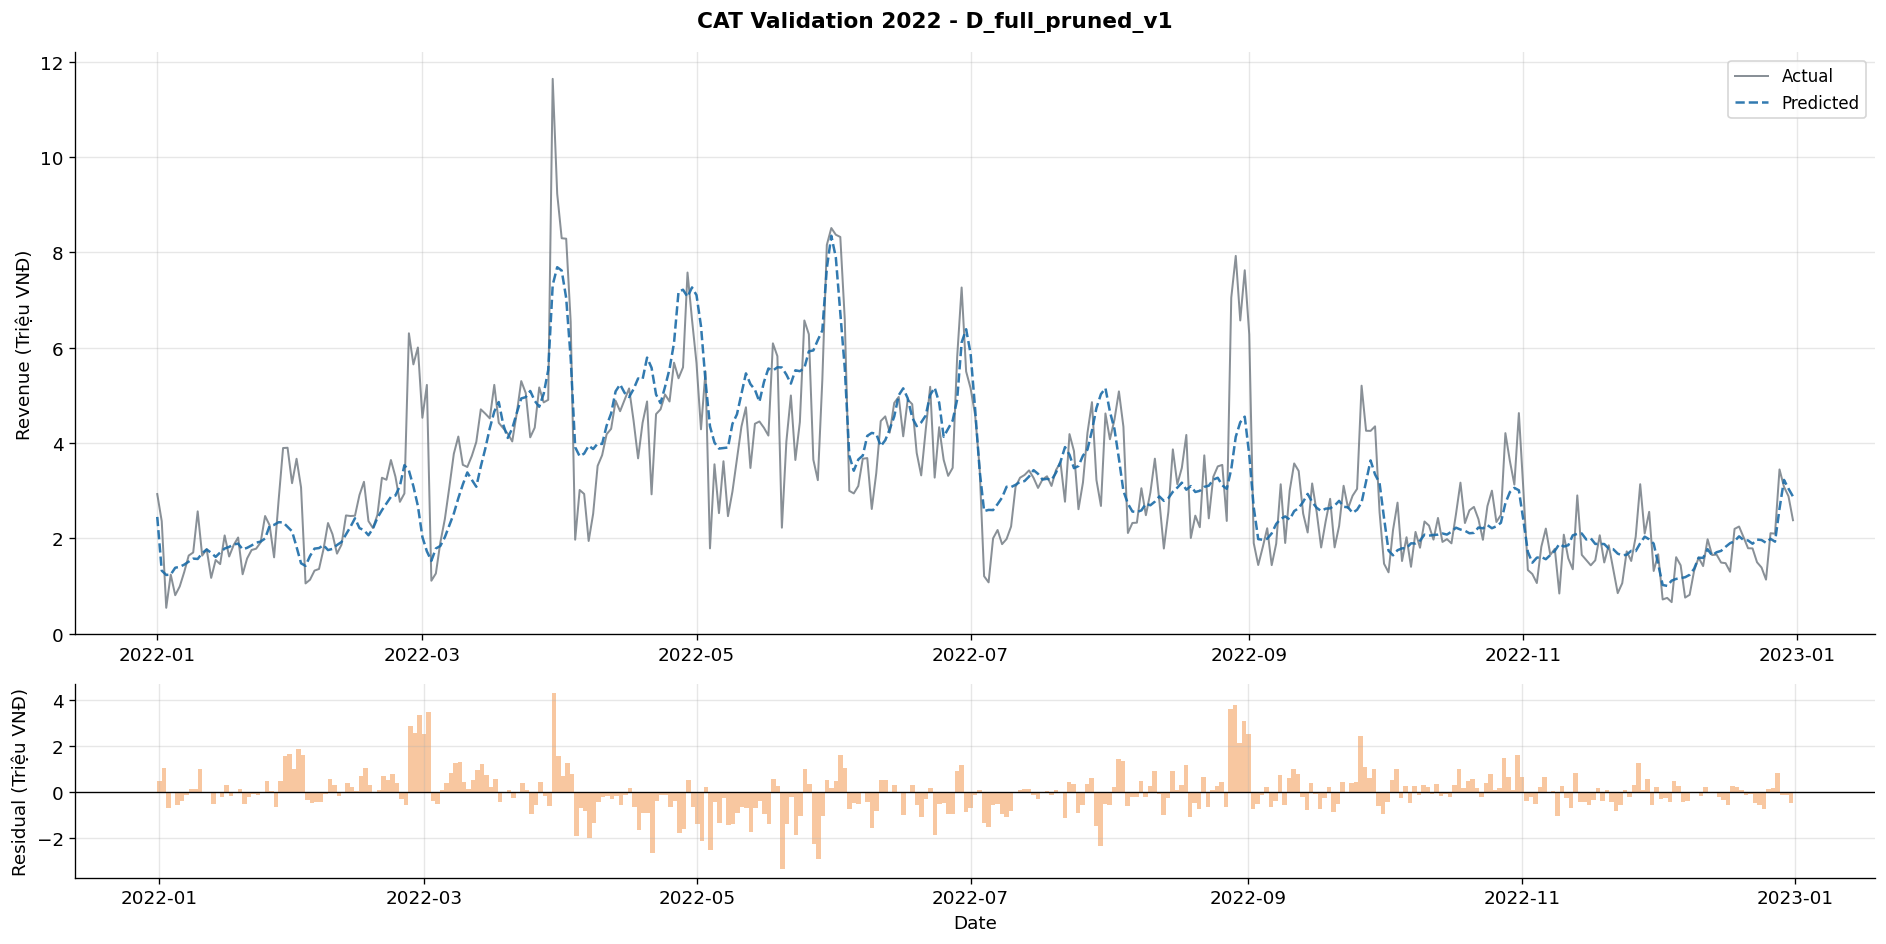


Comparison with baselines:
  Model                              MAE         RMSE       R2
  ------------------------- ------------ ------------ --------
  Seasonal Naive                 837,704    1,161,819    0.518
  Monthly Median               1,304,900    1,637,367    0.043
  Seasonal Growth                698,524      943,422    0.682
  LGBM                           775,873    1,030,318    0.621
  XGB                            760,128    1,037,467    0.616
  CAT                            665,030      958,019    0.672
  ENS_FIXED                      681,287      960,102    0.671
  SELECTED (CAT)                 665,030      958,019    0.672


In [9]:
best_art = ablation_artifacts[best_config_name]

if best_model_name == "LGBM":
    selected_val_pred = best_art["lgbm_val"]
elif best_model_name == "XGB":
    selected_val_pred = best_art["xgb_val"]
elif best_model_name == "CAT" and best_art["cat_val"] is not None:
    selected_val_pred = best_art["cat_val"]
else:
    selected_val_pred = best_w_lgbm * best_art["lgbm_val"] + best_w_xgb * best_art["xgb_val"]
    if best_art["cat_val"] is not None:
        selected_val_pred += best_w_catboost * best_art["cat_val"]
selected_val_pred = np.maximum(selected_val_pred, 0)

plot_actual_vs_predicted(
    dates=valid_df["Date"].values,
    y_true=valid_df["Revenue"].values,
    y_pred=selected_val_pred,
    title=f"{best_model_name} Validation 2022 - {best_config_name}",
)

print()
print("Comparison with baselines:")
comparison = [
    ("Seasonal Naive",  seasonal_m),
    ("Monthly Median",  monthly_m),
    ("Seasonal Growth", sgb_m),
    ("LGBM",            best_art["lgbm_metrics"]),
    ("XGB",             best_art["xgb_metrics"]),
]
if best_art["cat_metrics"] is not None:
    comparison.append(("CAT", best_art["cat_metrics"]))
comparison.append(("ENS_FIXED", best_art["ens_metrics"]))
comparison.append((f"SELECTED ({best_model_name})", best_selected_metrics))

print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R2':>8}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*8}")
for name, m in comparison:
    print(f"  {name:<25} {m['MAE']:>12,.0f} {m['RMSE']:>12,.0f} {m['R2']:>8.3f}")


## Section 5b - Prophet Diagnostic Only

Section này chỉ giữ Prophet như một **diagnostic tùy chọn**, không còn là phần của flow chính.

Lý do:
- Prophet không cho thấy lợi thế rõ ràng trong bài toán hiện tại.
- Mục tiêu bây giờ là tối ưu long-horizon framework, không phải thêm một model phụ để pha blend.

Nếu muốn thử lại Prophet, chỉ cần bật `USE_PROPHET_BLEND = True` ở cell code bên dưới.




In [10]:
USE_PROPHET_BLEND = False
PROPHET_BLEND_WEIGHT = 0.10 if USE_PROPHET_BLEND else 0.0

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as exc:
    Prophet = None
    PROPHET_AVAILABLE = False
    PROPHET_BLEND_WEIGHT = 0.0
    print(f"Prophet unavailable: {type(exc).__name__}: {exc}")
    print("To try Prophet, install it in this environment: pip install prophet")


def _prophet_holidays_until(end_date):
    tet_dates = pd.to_datetime([
        "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
        "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
        "2022-02-01", "2023-01-22", "2024-02-10",
    ])
    rows = []
    end_date = pd.Timestamp(end_date)
    for dt in tet_dates:
        if dt <= end_date:
            rows.append({"holiday": "tet", "ds": dt, "lower_window": -21, "upper_window": 7})
    for year in range(2012, end_date.year + 1):
        for month, day in [(1, 1), (4, 30), (5, 1), (9, 2), (11, 11), (12, 12)]:
            dt = pd.Timestamp(year=year, month=month, day=day)
            if dt <= end_date:
                rows.append({"holiday": f"event_{month}_{day}", "ds": dt, "lower_window": -3, "upper_window": 2})
    return pd.DataFrame(rows)


def prophet_forecast_revenue(train_data, forecast_dates):
    if not PROPHET_AVAILABLE:
        return None
    train_prophet = train_data[["Date", "Revenue"]].rename(columns={"Date": "ds", "Revenue": "y"}).copy()
    train_prophet["y"] = np.log1p(train_prophet["y"].clip(lower=0))
    forecast_dates = pd.to_datetime(list(forecast_dates))
    holidays = _prophet_holidays_until(max(train_prophet["ds"].max(), forecast_dates.max()))
    model = Prophet(
        holidays=holidays,
        yearly_seasonality=20,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        holidays_prior_scale=10.0,
    )
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    model.fit(train_prophet)
    future = pd.DataFrame({"ds": forecast_dates})
    forecast = model.predict(future)
    return np.maximum(np.expm1(forecast["yhat"].to_numpy(dtype=float)), 0.0)


prophet_valid_pred = None
if USE_PROPHET_BLEND and PROPHET_AVAILABLE:
    print("Fitting Prophet validation diagnostic...")
    prophet_valid_pred = prophet_forecast_revenue(train_df, valid_df["Date"])
    prophet_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_valid_pred)
    tree_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred)
    prophet_blend_pred = (
        (1.0 - PROPHET_BLEND_WEIGHT) * selected_val_pred
        + PROPHET_BLEND_WEIGHT * prophet_valid_pred
    )
    prophet_blend_pred = np.maximum(prophet_blend_pred, 0)
    prophet_blend_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_blend_pred)
    display(pd.DataFrame([
        {"candidate": "TREE_SELECTED", **tree_metrics},
        {"candidate": "PROPHET", **prophet_metrics},
        {"candidate": f"TREE_{1-PROPHET_BLEND_WEIGHT:.0%}_PROPHET_{PROPHET_BLEND_WEIGHT:.0%}", **prophet_blend_metrics},
    ]))
    print(f"Prophet diagnostic blend weight: {PROPHET_BLEND_WEIGHT:.2f}")
else:
    print("Prophet diagnostic skipped. Main flow stays tree-based.")



Prophet diagnostic skipped. Main flow stays tree-based.


## Section 5c - Business Shape And COGS Ratio Calibration

Section này dùng dữ liệu transaction/review/return theo cách future-safe.

- `Component shape`: tạo seasonal shape từ `orders_count`, `qty_per_order`, `gross_per_qty`, rồi normalize về cùng mean với base prediction. Cách này chỉ chỉnh hình dạng theo ngày, không kéo toàn bộ level xuống như decomposition cũ.
- `COGS ratio model`: train model riêng cho tỷ lệ `COGS / Revenue`, rồi chọn blend với monthly ratio baseline theo MAE trên holdout 2022.

Các weight được chọn trên validation 2022 và áp dụng lại cho test.


In [11]:
component_profile_valid = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=train_df,
    train_cutoff=train_df["Date"].max(),
)
component_shape_valid = forecast_component_shape(component_profile_valid, valid_df["Date"])

component_rows = []
for weight in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    pred = blend_with_normalized_shape(selected_val_pred, component_shape_valid["Revenue"].to_numpy(dtype=float), weight)
    m = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), pred)
    component_rows.append({"component_shape_weight": weight, **m})
component_shape_df = pd.DataFrame(component_rows).sort_values("MAE").reset_index(drop=True)
COMPONENT_SHAPE_WEIGHT = float(component_shape_df.iloc[0]["component_shape_weight"])

cogs_monthly_valid = predict_cogs(selected_val_pred, valid_df["Date"], train_df)
cogs_ratio_model_valid, ratio_valid = forecast_cogs_ratio_model(
    train_df,
    selected_val_pred,
    valid_df["Date"],
    best_promo_profile,
    traffic_profile=best_traffic_profile,
    inventory_profile=best_inventory_profile,
    business_daily=best_business_daily,
    business_profile=best_business_profile,
    business_groups=best_business_groups,
)

cogs_rows = []
for weight in [0.0, 0.25, 0.50, 0.75, 1.0]:
    cogs_pred = (1.0 - weight) * cogs_monthly_valid + weight * cogs_ratio_model_valid
    cogs_pred = np.minimum(np.maximum(cogs_pred, 0), np.maximum(selected_val_pred, 0) * 0.995)
    m = compute_metrics(valid_df["COGS"].to_numpy(dtype=float), cogs_pred)
    cogs_rows.append({"cogs_ratio_model_weight": weight, **m})
cogs_ratio_df = pd.DataFrame(cogs_rows).sort_values("MAE").reset_index(drop=True)
COGS_RATIO_MODEL_WEIGHT = float(cogs_ratio_df.iloc[0]["cogs_ratio_model_weight"])

print("Component shape validation:")
display(component_shape_df)
print(f"Selected component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print()
print("COGS ratio validation:")
display(cogs_ratio_df)
print(f"Selected COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")


Component shape validation:


,component_shape_weight,MAE,RMSE,R2
0,0.30,615539.409266,886664.305335,0.719388
1,0.20,625671.121574,901980.875050,0.709610
2,0.15,633456.551040,912933.420865,0.702514
3,0.10,642690.472055,925983.449109,0.693949
4,0.05,653273.160248,941043.702615,0.683913
5,0.00,665030.364561,958019.382662,0.672406


Selected component shape weight: 0.30

COGS ratio validation:


,cogs_ratio_model_weight,MAE,RMSE,R2
0,1.00,584887.434400,826979.678080,0.678533
1,0.75,585183.422191,831903.282888,0.674694
2,0.50,586283.919948,838753.688021,0.669314
3,0.25,590131.795087,847484.170486,0.662394
4,0.00,595472.568560,858037.343153,0.653934


Selected COGS ratio model weight: 1.00


## Section 5d - Long-Horizon Backtest 548 Days

Section này mô phỏng sát bài thi hơn bằng cách:
- train trên quá khứ
- forecast thẳng **548 ngày** liên tiếp
- tune các weight framework thay vì tune hyperparameter model

Các weight được tune:
- `FINAL_ANCHOR_WEIGHT`: mức kéo recursive forecast về seasonal anchor
- `COMPONENT_SHAPE_WEIGHT`: mức blend shape từ component profile
- `COGS_RATIO_MODEL_WEIGHT`: mức blend giữa monthly ratio baseline và ratio model

Mục tiêu tối ưu là:

```text
Total_MAE = Revenue_MAE + COGS_MAE
```

Đây là objective gần bài thi hơn nhiều so với chỉ nhìn holdout 2022 một năm.




In [12]:
LONG_HORIZON_DAYS = len(sample_sub)
LONG_HORIZON_END = sales["Date"].max()
LONG_HORIZON_START = LONG_HORIZON_END - pd.Timedelta(days=LONG_HORIZON_DAYS - 1)

long_valid_df = sales[sales["Date"] >= LONG_HORIZON_START].copy().reset_index(drop=True)
long_train_df = sales[sales["Date"] < LONG_HORIZON_START].copy().reset_index(drop=True)

print(f"Long-horizon backtest train: {long_train_df['Date'].min().date()} -> {long_train_df['Date'].max().date()} ({len(long_train_df)} rows)")
print(f"Long-horizon backtest valid: {long_valid_df['Date'].min().date()} -> {long_valid_df['Date'].max().date()} ({len(long_valid_df)} rows)")

long_profile_cutoff = long_train_df["Date"].max()
(
    long_promo_profile,
    long_traffic_profile,
    long_inventory_profile,
    long_business_daily,
    long_business_profile,
    long_business_groups,
) = _profiles_for_flags(best_config_flags, long_profile_cutoff)

long_frame, long_feat_cols = make_supervised_frame(
    long_train_df,
    long_promo_profile,
    traffic_profile=long_traffic_profile,
    inventory_profile=long_inventory_profile,
    business_daily=long_business_daily,
    business_profile=long_business_profile,
    business_groups=long_business_groups,
)
long_drop_cols = [c for c in best_config_flags.get("drop_cols", []) if c in long_feat_cols]
long_feat_cols = [c for c in long_feat_cols if c not in long_drop_cols]

X_long_raw = long_frame[long_feat_cols].copy()
y_long_log = np.log1p(long_frame["Revenue"].clip(lower=0)).copy()
X_long, long_fill_values = impute_feature_frame(X_long_raw, fill_values=best_feature_fill_values)

long_eval_size = min(365, max(90, len(X_long) // 5))
X_long_fit, X_long_eval = X_long.iloc[:-long_eval_size], X_long.iloc[-long_eval_size:]
y_long_fit, y_long_eval = y_long_log.iloc[:-long_eval_size], y_long_log.iloc[-long_eval_size:]

long_lgbm = lgb.LGBMRegressor(**LGBM_PARAMS)
long_lgbm.fit(
    X_long_fit,
    y_long_fit,
    callbacks=[lgb.early_stopping(200, verbose=False)],
    eval_set=[(X_long_eval, y_long_eval)],
)

long_xgb = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=200)
long_xgb.fit(
    X_long_fit,
    y_long_fit,
    eval_set=[(X_long_eval, y_long_eval)],
    verbose=False,
)

long_cat = None
if CatBoostRegressor is not None:
    long_cat = CatBoostRegressor(**CATBOOST_PARAMS)
    long_cat.fit(
        X_long_fit,
        y_long_fit,
        eval_set=(X_long_eval, y_long_eval),
        use_best_model=False,
        verbose=False,
    )

long_component_profile = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=long_train_df,
    train_cutoff=long_profile_cutoff,
)
long_component_shape = forecast_component_shape(long_component_profile, long_valid_df["Date"])
long_anchor_base = seasonal_growth_baseline(long_train_df, long_valid_df["Date"], "Revenue")
long_y_revenue = long_valid_df["Revenue"].to_numpy(dtype=float)
long_y_cogs = long_valid_df["COGS"].to_numpy(dtype=float)

anchor_grid = [0.00, 0.05, 0.10, 0.15, 0.20]
component_grid = [0.00, 0.05, 0.10, 0.15, 0.20]
cogs_grid = [0.00, 0.25, 0.50, 0.75, 1.00]

anchor_cache = {}
for anchor_weight in anchor_grid:
    lgbm_pred = recursive_forecast(
        long_lgbm, long_train_df, long_valid_df["Date"], long_feat_cols, long_promo_profile,
        traffic_profile=long_traffic_profile,
        inventory_profile=long_inventory_profile,
        business_daily=long_business_daily,
        business_profile=long_business_profile,
        business_groups=long_business_groups,
        feature_fill_values=long_fill_values,
        anchor_pred=long_anchor_base,
        blend_weight=anchor_weight,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    lgbm_pred = calibrate_monthly_predictions(lgbm_pred, long_valid_df["Date"], long_train_df, "Revenue")

    xgb_pred = recursive_forecast(
        long_xgb, long_train_df, long_valid_df["Date"], long_feat_cols, long_promo_profile,
        traffic_profile=long_traffic_profile,
        inventory_profile=long_inventory_profile,
        business_daily=long_business_daily,
        business_profile=long_business_profile,
        business_groups=long_business_groups,
        feature_fill_values=long_fill_values,
        anchor_pred=long_anchor_base,
        blend_weight=anchor_weight,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    xgb_pred = calibrate_monthly_predictions(xgb_pred, long_valid_df["Date"], long_train_df, "Revenue")

    cat_pred = None
    if long_cat is not None:
        cat_pred = recursive_forecast(
            long_cat, long_train_df, long_valid_df["Date"], long_feat_cols, long_promo_profile,
            traffic_profile=long_traffic_profile,
            inventory_profile=long_inventory_profile,
            business_daily=long_business_daily,
            business_profile=long_business_profile,
            business_groups=long_business_groups,
            feature_fill_values=long_fill_values,
            anchor_pred=long_anchor_base,
            blend_weight=anchor_weight,
            ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
            predict_log_target=True,
        )
        cat_pred = calibrate_monthly_predictions(cat_pred, long_valid_df["Date"], long_train_df, "Revenue")

    ens_pred = best_w_lgbm * lgbm_pred + best_w_xgb * xgb_pred
    if cat_pred is not None:
        ens_pred += best_w_catboost * cat_pred
    ens_pred = np.maximum(ens_pred, 0)

    if best_model_name == "LGBM":
        selected_base_pred = lgbm_pred.copy()
    elif best_model_name == "XGB":
        selected_base_pred = xgb_pred.copy()
    elif best_model_name == "CAT" and cat_pred is not None:
        selected_base_pred = cat_pred.copy()
    else:
        selected_base_pred = ens_pred.copy()

    anchor_cache[anchor_weight] = {
        "LGBM": lgbm_pred,
        "XGB": xgb_pred,
        "CAT": cat_pred,
        "ENS": ens_pred,
        "SELECTED": np.maximum(selected_base_pred, 0),
    }

long_rows = []
for anchor_weight, preds in anchor_cache.items():
    base_pred = preds["SELECTED"]
    for component_weight in component_grid:
        revenue_pred = blend_with_normalized_shape(
            base_pred,
            long_component_shape["Revenue"].to_numpy(dtype=float),
            component_weight,
        )
        revenue_pred = np.maximum(revenue_pred, 0)
        revenue_metrics = compute_metrics(long_y_revenue, revenue_pred)

        cogs_monthly_bt = predict_cogs(revenue_pred, long_valid_df["Date"], long_train_df)
        cogs_ratio_model_bt, _ = forecast_cogs_ratio_model(
            long_train_df,
            revenue_pred,
            long_valid_df["Date"],
            long_promo_profile,
            traffic_profile=long_traffic_profile,
            inventory_profile=long_inventory_profile,
            business_daily=long_business_daily,
            business_profile=long_business_profile,
            business_groups=long_business_groups,
        )

        for cogs_weight in cogs_grid:
            cogs_pred = (1.0 - cogs_weight) * cogs_monthly_bt + cogs_weight * cogs_ratio_model_bt
            cogs_pred = np.minimum(np.maximum(cogs_pred, 0), revenue_pred * 0.995)
            cogs_metrics = compute_metrics(long_y_cogs, cogs_pred)
            total_mae = float(revenue_metrics["MAE"] + cogs_metrics["MAE"])
            long_rows.append({
                "anchor_weight": anchor_weight,
                "component_shape_weight": component_weight,
                "cogs_ratio_weight": cogs_weight,
                "Revenue_MAE": revenue_metrics["MAE"],
                "Revenue_RMSE": revenue_metrics["RMSE"],
                "Revenue_R2": revenue_metrics["R2"],
                "COGS_MAE": cogs_metrics["MAE"],
                "COGS_RMSE": cogs_metrics["RMSE"],
                "COGS_R2": cogs_metrics["R2"],
                "Total_MAE": total_mae,
            })

long_horizon_df = pd.DataFrame(long_rows).sort_values(["Total_MAE", "Revenue_MAE", "COGS_MAE"]).reset_index(drop=True)
LONG_HORIZON_BEST = long_horizon_df.iloc[0].to_dict()
FINAL_ANCHOR_WEIGHT = float(LONG_HORIZON_BEST["anchor_weight"])
COMPONENT_SHAPE_WEIGHT = float(LONG_HORIZON_BEST["component_shape_weight"])
COGS_RATIO_MODEL_WEIGHT = float(LONG_HORIZON_BEST["cogs_ratio_weight"])

print("Top long-horizon combinations:")
display(long_horizon_df.head(15))
print(f"Selected FINAL_ANCHOR_WEIGHT    : {FINAL_ANCHOR_WEIGHT:.2f}")
print(f"Selected COMPONENT_SHAPE_WEIGHT: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"Selected COGS_RATIO_MODEL_WEIGHT: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print(f"Best long-horizon Total_MAE     : {LONG_HORIZON_BEST['Total_MAE']:,.0f}")



Long-horizon backtest train: 2012-07-04 -> 2021-07-01 (3285 rows)
Long-horizon backtest valid: 2021-07-02 -> 2022-12-31 (548 rows)
Top long-horizon combinations:


,anchor_weight,component_shape_weight,cogs_ratio_weight,Revenue_MAE,Revenue_RMSE,Revenue_R2,COGS_MAE,COGS_RMSE,COGS_R2,Total_MAE
0,0.00,0.20,1.00,705069.877244,9.955251e+05,0.589085,627716.154999,892561.007439,0.573867,1.332786e+06
1,0.00,0.20,0.75,705069.877244,9.955251e+05,0.589085,634001.208926,906188.370547,0.560755,1.339071e+06
2,0.05,0.20,1.00,708062.130631,1.004282e+06,0.581824,635846.923568,907307.854522,0.559669,1.343909e+06
3,0.00,0.15,1.00,712662.971335,1.013616e+06,0.574015,633492.942280,904181.820401,0.562698,1.346156e+06
4,0.00,0.20,0.50,705069.877244,9.955251e+05,0.589085,642232.806878,921741.576722,0.545548,1.347303e+06
5,0.05,0.20,0.75,708062.130631,1.004282e+06,0.581824,643498.477495,921493.333916,0.545793,1.351561e+06
6,0.00,0.15,0.75,712662.971335,1.013616e+06,0.574015,639704.255562,917493.010275,0.549728,1.352367e+06
7,0.05,0.15,1.00,715056.474393,1.020285e+06,0.568391,641193.253625,917022.488555,0.550190,1.356250e+06
8,0.00,0.20,0.25,705069.877244,9.955251e+05,0.589085,652264.208256,939124.946973,0.528245,1.357334e+06
9,0.00,0.15,0.50,712662.971335,1.013616e+06,0.574015,647707.077005,932692.257192,0.534686,1.360370e+06


Selected FINAL_ANCHOR_WEIGHT    : 0.00
Selected COMPONENT_SHAPE_WEIGHT: 0.20
Selected COGS_RATIO_MODEL_WEIGHT: 1.00
Best long-horizon Total_MAE     : 1,332,786


## Section 6 - Final Training On Full History

Sau khi chọn candidate bằng validation, section này train lại model trên toàn bộ lịch sử 2012-2022.

Lý do train lại:

- Khi nộp bài, mình được phép dùng toàn bộ dữ liệu lịch sử đã công bố.
- Validation 2022 chỉ dùng để chọn model, không phải để bỏ đi khi train final.

Các cell trong section này build full feature matrix và train final LGBM/XGB/CatBoost.


### 6.1 Build Full Training Matrix

Cell code bên dưới build supervised training frame cho toàn bộ lịch sử.

Nó dùng `best_config_flags` từ validation để quyết định có dùng promo/traffic/inventory hay không.

Output chính:

- `X_full`: feature matrix sau imputation.
- `y_full_log`: target `log1p(Revenue)`.
- `feat_cols_full`: danh sách feature dùng cho final model.
- `feature_medians_full`: giá trị fill dùng cho recursive forecasting.


In [13]:
# Build full supervised frame (train trên toàn bộ 2012-2022)
FULL_PROFILE_CUTOFF = sales["Date"].max()
(
    final_promo_profile,
    final_traffic_profile,
    final_inventory_profile,
    final_business_daily,
    final_business_profile,
    final_business_groups,
) = _profiles_for_flags(best_config_flags, FULL_PROFILE_CUTOFF)
final_component_profile = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=sales,
    train_cutoff=FULL_PROFILE_CUTOFF,
)

frame_full, feat_cols_full = make_supervised_frame(
    sales,
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
)

final_drop_cols = [c for c in best_config_flags.get("drop_cols", []) if c in feat_cols_full]
feat_cols_full = [c for c in feat_cols_full if c not in final_drop_cols]

X_full_raw = frame_full[feat_cols_full].copy()
y_full_log = np.log1p(frame_full["Revenue"].clip(lower=0)).copy()
dates_full = frame_full["Date"].values

X_full, feature_medians_full = impute_feature_frame(X_full_raw, fill_values=best_feature_fill_values)

print(f"Full profile cutoff: {FULL_PROFILE_CUTOFF.date()}")
print(f"Full train: {X_full.shape[0]:,} rows × {X_full.shape[1]} features")
if final_drop_cols:
    print(f"Final pruned columns: {len(final_drop_cols)}")
print(f"Final business groups: {final_business_groups if final_business_groups else 'disabled'}")
print(f"Final anchor weight: {FINAL_ANCHOR_WEIGHT:.2f}")
print(f"Component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print(f"Date range: {pd.Series(dates_full).min()} to {pd.Series(dates_full).max()}")
print("Target transform: log1p(Revenue); recursive predictions use expm1 inverse.")




Full profile cutoff: 2022-12-31
Full train: 3,468 rows × 119 features
Final pruned columns: 27
Final business groups: disabled
Final anchor weight: 0.00
Component shape weight: 0.20
COGS ratio model weight: 1.00
Date range: 2013-07-04 00:00:00 to 2022-12-31 00:00:00
Target transform: log1p(Revenue); recursive predictions use expm1 inverse.


### 6.2 Internal TimeSeries CV For Iteration Count

Cell code bên dưới chạy TimeSeriesSplit để lấy số vòng train hợp lý cho final model.

Lưu ý quan trọng:

- Metric trong cell này đang ở log scale, nên MAE/RMSE có thể nhìn rất nhỏ hoặc bị format thành 0.
- Cell này không dùng để chọn model cuối.
- Model cuối vẫn được chọn bằng original-scale holdout metrics ở Section 4.

Vai trò chính của cell: tránh final model dùng số iteration quá thấp.

#### **Kết quả 5-Fold TimeSeries CV này là gì?**

Cell này dùng để đánh giá nhanh độ ổn định của từng mô hình trên dữ liệu lịch sử theo cách tôn trọng thứ tự thời gian.

Cụ thể, mỗi mô hình (`LightGBM`, `XGBoost`, `CatBoost`) được chạy với `TimeSeriesSplit`, nghĩa là:

- train trên quá khứ
- validate trên một giai đoạn thời gian nằm sau tập train
- lặp lại nhiều fold để xem mô hình có ổn định qua các năm hay không

Khác với `K-Fold` thông thường, `TimeSeriesSplit` không xáo trộn dữ liệu. Điều này rất quan trọng vì bài toán hiện tại là dự báo chuỗi thời gian, nên tuyệt đối không được để mô hình “nhìn thấy tương lai” khi train.

#### Mục đích của cell này

Cell này không dùng để tạo submission trực tiếp.

Vai trò chính của nó là:

- kiểm tra mô hình nào học pattern lịch sử tốt hơn
- so sánh độ ổn định của các mô hình qua nhiều giai đoạn thời gian
- hỗ trợ lựa chọn mô hình hoặc số vòng train hợp lý
- phát hiện dấu hiệu overfitting nếu performance giữa các fold dao động quá mạnh




In [14]:
# TimeSeriesSplit CV (5-fold) - lấy best_iter trên log target cho final training
# Metrics in this table are on log scale; holdout metrics above are the decision metrics on original scale.
tscv = TimeSeriesCV(n_splits=5, test_size=365)

print("Running 5-fold TimeSeriesCV for LightGBM on log target...")
cv_results_lgbm, oof_lgbm, _ = tscv.cross_validate_lgbm(
    X_full.values, y_full_log.values, dates_full
)
print_cv_table(cv_results_lgbm, "LightGBM (log target)")
best_lgbm_iter = max(1500, int(cv_results_lgbm["best_iter"].mean()))

print()
print("Running 5-fold TimeSeriesCV for XGBoost on log target...")
cv_results_xgb, oof_xgb, _ = tscv.cross_validate_xgb(
    X_full.values, y_full_log.values, dates_full
)
print_cv_table(cv_results_xgb, "XGBoost (log target)")
best_xgb_iter = max(1500, int(cv_results_xgb["best_iter"].mean()))

best_cat_iter = None
if CatBoostRegressor is not None:
    print()
    print("Running 5-fold TimeSeriesCV for CatBoost on log target...")
    cv_results_cat, oof_cat, _ = tscv.cross_validate_catboost(
        X_full.values, y_full_log.values, dates_full
    )
    print_cv_table(cv_results_cat, "CatBoost (log target)")
    valid_iters = cv_results_cat["best_iter"].dropna()
    best_cat_iter = max(1500, int(valid_iters.mean())) if len(valid_iters) else CATBOOST_PARAMS["iterations"]
else:
    print()
    print("Skipping CatBoost CV (package not installed)")


Running 5-fold TimeSeriesCV for LightGBM on log target...
[500]	valid_0's l1: 0.170575
  Fold 1 LGBM best_iteration=637
[500]	valid_0's l1: 0.202299
  Fold 2 LGBM best_iteration=625
  Fold 3 LGBM best_iteration=202
  Fold 4 LGBM best_iteration=115
  Fold 5 LGBM best_iteration=113
────────────────────────────────────────────────────────────────────────────────
  LightGBM (log target) — 5-Fold TimeSeriesSplit CV Results
────────────────────────────────────────────────────────────────────────────────
  Fold     Train Val Period                                 MAE       RMSE       R²
  ───── ──────── ─────────────────────────────────── ────────── ────────── ────────
  1        1,643 2018-01-02 → 2019-01-01                      0          0    0.864
  2        2,008 2019-01-02 → 2020-01-01                      0          0    0.748
  3        2,373 2020-01-02 → 2020-12-31                      0          0    0.764
  4        2,738 2021-01-01 → 2021-12-31                      0          0   

## Section 6a - Optuna Diagnostic Only

Section này giữ lại Optuna như một **diagnostic tùy chọn**. Mặc định notebook không dùng Optuna trong flow chính.

Lý do:
- Optuna chưa cho thấy cải thiện leaderboard rõ ràng.
- Bài toán hiện tại bị chi phối nhiều hơn bởi long-horizon drift và calibration framework.

Nếu muốn chạy lại Optuna, chỉ cần bật `USE_OPTUNA_CATBOOST = True`.




In [15]:
USE_OPTUNA_CATBOOST = False
OPTUNA_CATBOOST_TRIALS = 24
OPTUNA_CATBOOST_TIMEOUT_SEC = None

catboost_final_params = CATBOOST_PARAMS.copy()
catboost_final_best_iter = None
catboost_tuned_metrics = None
catboost_tuned_val = None

try:
    import optuna
    from optuna.samplers import TPESampler
    OPTUNA_AVAILABLE = True
except Exception as exc:
    optuna = None
    OPTUNA_AVAILABLE = False
    print(f"Optuna unavailable: {type(exc).__name__}: {exc}")
    print("To run CatBoost tuning, install Optuna in this environment: pip install optuna")

if USE_OPTUNA_CATBOOST and OPTUNA_AVAILABLE and CatBoostRegressor is not None:
    print("Running Optuna diagnostic for CatBoost on the current best config...")

    tune_frame, tune_feat_cols = make_supervised_frame(
        train_df,
        best_promo_profile,
        traffic_profile=best_traffic_profile,
        inventory_profile=best_inventory_profile,
        business_daily=best_business_daily,
        business_profile=best_business_profile,
        business_groups=best_business_groups,
    )
    tune_drop_cols = [c for c in best_config_flags.get("drop_cols", []) if c in tune_feat_cols]
    tune_feat_cols = [c for c in tune_feat_cols if c not in tune_drop_cols]

    X_tune_raw = tune_frame[tune_feat_cols].copy()
    y_tune_log = np.log1p(tune_frame["Revenue"].clip(lower=0)).copy()
    X_tune, tune_fill_values = impute_feature_frame(X_tune_raw, fill_values=best_feature_fill_values)

    eval_size = min(365, max(90, len(X_tune) // 5))
    X_fit, X_eval = X_tune.iloc[:-eval_size], X_tune.iloc[-eval_size:]
    y_fit, y_eval = y_tune_log.iloc[:-eval_size], y_tune_log.iloc[-eval_size:]
    seasonal_anchor = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
    y_valid_target = valid_df["Revenue"].to_numpy(dtype=float)

    def optuna_cat_objective(trial):
        params = CATBOOST_PARAMS.copy()
        params.update({
            "iterations": trial.suggest_int("iterations", 2000, 5000, step=500),
            "depth": trial.suggest_int("depth", 6, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 15.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.5),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
            "subsample": trial.suggest_float("subsample", 0.70, 1.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 60, step=5),
        })

        model = CatBoostRegressor(**params)
        model.fit(
            X_fit, y_fit,
            eval_set=(X_eval, y_eval),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=False,
        )

        pred = recursive_forecast(
            model, train_df, valid_df["Date"], tune_feat_cols, best_promo_profile,
            traffic_profile=best_traffic_profile,
            inventory_profile=best_inventory_profile,
            business_daily=best_business_daily,
            business_profile=best_business_profile,
            business_groups=best_business_groups,
            feature_fill_values=tune_fill_values,
            anchor_pred=seasonal_anchor,
            blend_weight=RECURSIVE_BLEND_WEIGHT,
            ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
            predict_log_target=True,
        )
        pred = calibrate_monthly_predictions(pred, valid_df["Date"], train_df, "Revenue")
        metrics = compute_metrics(y_valid_target, pred)

        try:
            best_iter = int(model.get_best_iteration())
        except Exception:
            best_iter = int(params["iterations"])
        trial.set_user_attr("best_iter", best_iter)
        trial.set_user_attr("RMSE", float(metrics["RMSE"]))
        trial.set_user_attr("R2", float(metrics["R2"]))
        return float(metrics["MAE"])

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(
        optuna_cat_objective,
        n_trials=OPTUNA_CATBOOST_TRIALS,
        timeout=OPTUNA_CATBOOST_TIMEOUT_SEC,
        show_progress_bar=False,
    )

    best_trial = study.best_trial
    catboost_final_params = CATBOOST_PARAMS.copy()
    catboost_final_params.update(best_trial.params)
    catboost_final_best_iter = int(best_trial.user_attrs.get("best_iter", best_trial.params["iterations"]))

    tuned_cat_model = CatBoostRegressor(**catboost_final_params)
    tuned_cat_model.fit(
        X_fit, y_fit,
        eval_set=(X_eval, y_eval),
        use_best_model=True,
        early_stopping_rounds=200,
        verbose=False,
    )
    try:
        catboost_final_best_iter = int(tuned_cat_model.get_best_iteration())
    except Exception:
        catboost_final_best_iter = int(catboost_final_params.get("iterations", catboost_final_best_iter))

    catboost_tuned_val = recursive_forecast(
        tuned_cat_model, train_df, valid_df["Date"], tune_feat_cols, best_promo_profile,
        traffic_profile=best_traffic_profile,
        inventory_profile=best_inventory_profile,
        business_daily=best_business_daily,
        business_profile=best_business_profile,
        business_groups=best_business_groups,
        feature_fill_values=tune_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    catboost_tuned_val = calibrate_monthly_predictions(catboost_tuned_val, valid_df["Date"], train_df, "Revenue")
    catboost_tuned_metrics = compute_metrics(y_valid_target, catboost_tuned_val)

    base_cat_metrics = best_artifact["cat_metrics"] if best_artifact["cat_metrics"] is not None else {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
    tuning_summary = pd.DataFrame([
        {"candidate": "CAT_CURRENT", **base_cat_metrics},
        {"candidate": "CAT_TUNED_OPTUNA", **catboost_tuned_metrics},
    ])
    display(tuning_summary)

    print("Optuna best params:")
    print(study.best_params)
    print(f"Optuna best iteration: {catboost_final_best_iter}")

    if np.isfinite(base_cat_metrics["MAE"]) and catboost_tuned_metrics["MAE"] < base_cat_metrics["MAE"]:
        print("Applying tuned CatBoost artifact because validation MAE improved.")
        best_artifact["cat_val"] = catboost_tuned_val
        best_artifact["cat_metrics"] = catboost_tuned_metrics
        best_artifact["cat_model"] = tuned_cat_model
        if catboost_tuned_metrics["MAE"] < best_selected_metrics["MAE"]:
            best_model_name = "CAT"
            best_selected_metrics = catboost_tuned_metrics
    else:
        print("Keeping current CatBoost artifact; Optuna did not improve holdout MAE.")
        catboost_final_params = CATBOOST_PARAMS.copy()
        catboost_final_best_iter = None
else:
    print("Skipping Optuna CatBoost diagnostic in main flow.")




Skipping Optuna CatBoost diagnostic in main flow.


### 6.3 Train Final Models

Cell code bên dưới train final LGBM, XGB và CatBoost trên toàn bộ dữ liệu lịch sử.

Các model này dự đoán log target, nên khi forecast tương lai cần inverse bằng `expm1`. Việc inverse được xử lý trong `recursive_forecast()` khi bật `predict_log_target=True`.


In [ ]:
print(f"Training final LightGBM (n_estimators={best_lgbm_iter}, log target)...")
final_lgbm = train_final_lgbm(X_full.values, y_full_log.values, best_iter=best_lgbm_iter)
print("  LightGBM done")

print(f"Training final XGBoost  (n_estimators={best_xgb_iter}, log target)...")
final_xgb = train_final_xgb(X_full.values, y_full_log.values, best_iter=best_xgb_iter)
print("  XGBoost done")

final_cat = None
if CatBoostRegressor is not None:
    final_cat_params = catboost_final_params.copy() if catboost_final_params is not None else CATBOOST_PARAMS.copy()
    cat_iter = catboost_final_best_iter if catboost_final_best_iter is not None else best_cat_iter
    if cat_iter is None:
        cat_iter = final_cat_params.get("iterations", CATBOOST_PARAMS["iterations"])
    print(f"Training final CatBoost (iterations={cat_iter}, log target)...")
    final_cat = train_final_catboost(
        X_full.values,
        y_full_log.values,
        best_iter=cat_iter,
        params=final_cat_params,
    )
    print("  CatBoost done")
    print(
        f"  Final CAT params: depth={final_cat_params.get('depth')} "
        f"lr={final_cat_params.get('learning_rate')} "
        f"l2={final_cat_params.get('l2_leaf_reg')} "
        f"bag_temp={final_cat_params.get('bagging_temperature')}"
    )
else:
    print("Skipping final CatBoost training (package not installed)")



Training final LightGBM (n_estimators=1500, log target)...


## Section 7 - Forecast Test Revenue

Section này forecast Revenue cho toàn bộ test horizon 548 ngày.

Điểm khó của bài này là horizon dài. Nếu chỉ recursive thuần, lỗi ở ngày đầu có thể lan sang các ngày sau. Vì vậy forecast trong notebook dùng thêm:

- `seasonal_growth_baseline` làm anchor.
- `RECURSIVE_BLEND_WEIGHT` để kéo prediction về baseline mùa vụ.
- `RECURSIVE_EWM_ALPHA` để smoothing prediction.
- Monthly calibration để tránh monthly mean lệch quá xa lịch sử.


### 7.1 Recursive Revenue Forecast For Test Dates

Cell code bên dưới tạo prediction từ từng model cho các ngày trong `sample_submission.csv`.

Các bước chính:

1. Tạo seasonal anchor cho toàn bộ test dates.
2. Chạy recursive forecast cho LGBM.
3. Chạy recursive forecast cho XGB.
4. Chạy recursive forecast cho CatBoost nếu có.
5. Tạo fixed ensemble.
6. `selected_test_pred` được đặt bằng fixed ensemble vì đây là candidate chính.

`selected_test_pred` là Revenue prediction dùng cho file submission chính trong single-holdout pipeline.


In [ ]:
USE_PROPHET_BLEND = False
PROPHET_BLEND_WEIGHT = 0.10 if USE_PROPHET_BLEND else 0.0

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as exc:
    Prophet = None
    PROPHET_AVAILABLE = False
    PROPHET_BLEND_WEIGHT = 0.0
    print(f"Prophet unavailable: {type(exc).__name__}: {exc}")
    print("To try Prophet, install it in this environment: pip install prophet")


def _prophet_holidays_until(end_date):
    tet_dates = pd.to_datetime([
        "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
        "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
        "2022-02-01", "2023-01-22", "2024-02-10",
    ])
    rows = []
    end_date = pd.Timestamp(end_date)
    for dt in tet_dates:
        if dt <= end_date:
            rows.append({"holiday": "tet", "ds": dt, "lower_window": -21, "upper_window": 7})
    for year in range(2012, end_date.year + 1):
        for month, day in [(1, 1), (4, 30), (5, 1), (9, 2), (11, 11), (12, 12)]:
            dt = pd.Timestamp(year=year, month=month, day=day)
            if dt <= end_date:
                rows.append({"holiday": f"event_{month}_{day}", "ds": dt, "lower_window": -3, "upper_window": 2})
    return pd.DataFrame(rows)


def prophet_forecast_revenue(train_data, forecast_dates):
    if not PROPHET_AVAILABLE:
        return None
    train_prophet = train_data[["Date", "Revenue"]].rename(columns={"Date": "ds", "Revenue": "y"}).copy()
    train_prophet["y"] = np.log1p(train_prophet["y"].clip(lower=0))
    forecast_dates = pd.to_datetime(list(forecast_dates))
    holidays = _prophet_holidays_until(max(train_prophet["ds"].max(), forecast_dates.max()))
    model = Prophet(
        holidays=holidays,
        yearly_seasonality=20,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        holidays_prior_scale=10.0,
    )
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    model.fit(train_prophet)
    future = pd.DataFrame({"ds": forecast_dates})
    forecast = model.predict(future)
    return np.maximum(np.expm1(forecast["yhat"].to_numpy(dtype=float)), 0.0)


prophet_valid_pred = None
if USE_PROPHET_BLEND and PROPHET_AVAILABLE:
    print("Fitting Prophet validation diagnostic...")
    prophet_valid_pred = prophet_forecast_revenue(train_df, valid_df["Date"])
    prophet_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_valid_pred)
    tree_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred)
    prophet_blend_pred = (
        (1.0 - PROPHET_BLEND_WEIGHT) * selected_val_pred
        + PROPHET_BLEND_WEIGHT * prophet_valid_pred
    )
    prophet_blend_pred = np.maximum(prophet_blend_pred, 0)
    prophet_blend_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_blend_pred)
    display(pd.DataFrame([
        {"candidate": "TREE_SELECTED", **tree_metrics},
        {"candidate": "PROPHET", **prophet_metrics},
        {"candidate": f"TREE_{1-PROPHET_BLEND_WEIGHT:.0%}_PROPHET_{PROPHET_BLEND_WEIGHT:.0%}", **prophet_blend_metrics},
    ]))
    print(f"Prophet diagnostic blend weight: {PROPHET_BLEND_WEIGHT:.2f}")
else:
    print("Prophet diagnostic skipped. Main flow stays tree-based.")



Predicting 548 test days recursively...
  Test: 2023-01-01 to 2024-07-01
  Running LightGBM recursive...
  Done
  Running XGBoost recursive...
  Done
  Running CatBoost recursive...
  Done
  Running Prophet direct forecast...


13:05:19 - cmdstanpy - INFO - Chain [1] start processing
13:05:21 - cmdstanpy - INFO - Chain [1] done processing


  Prophet blend done

Test predictions summary:
  LGBM                mean=4,265,456  min=1,091,491  max=11,925,200  zeros=0
  XGB                 mean=4,243,965  min=1,130,782  max=11,508,991  zeros=0
  CAT                 mean=4,067,156  min=1,275,712  max=9,747,832  zeros=0
  ENS_FIXED           mean=4,132,262  min=1,244,240  max=10,420,241  zeros=0
  PROPHET             mean=3,463,195  min=1,044,303  max=8,750,577  zeros=0
  SELECTED (CAT)      mean=4,006,760  min=1,226,812  max=10,777,656  zeros=0


## Section 8 - Predict COGS From Revenue Ratio

Section này dự báo COGS từ Revenue bằng tỷ lệ lịch sử giữa `COGS` và `Revenue`.

Lý do giữ cách này trong notebook chính:

- COGS tương quan rất mạnh với Revenue.
- Cách này ổn định và ít tạo giá trị bất thường.
- Notebook chính ưu tiên tạo file nộp sạch, không đưa thêm nhánh COGS experimental.


### 8.1 COGS For Final Ensemble

Cell code bên dưới chỉ tạo COGS cho fixed ensemble, vì đây là candidate chính được dùng để nộp.

Các prediction riêng của LGBM/XGB/CatBoost vẫn được dùng để tạo Revenue ensemble ở Section 7, nhưng không cần ghi thành các file submission riêng trong notebook gọn.


In [ ]:
cogs_monthly = predict_cogs(selected_test_pred, sample_sub["Date"], sales)
cogs_ratio_model, cogs_ratio_pred = forecast_cogs_ratio_model(
    sales,
    selected_test_pred,
    sample_sub["Date"],
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
)
cogs_ensemble = (1.0 - COGS_RATIO_MODEL_WEIGHT) * cogs_monthly + COGS_RATIO_MODEL_WEIGHT * cogs_ratio_model
cogs_ensemble = np.minimum(np.maximum(cogs_ensemble, 0), np.maximum(selected_test_pred, 0) * 0.995)
cogs_selected = cogs_ensemble.copy()

print(f"COGS prediction for selected candidate ({best_model_name}):")
print(f"  monthly ratio mean={cogs_monthly.mean():,.0f}")
print(f"  ratio model mean ={cogs_ratio_model.mean():,.0f}")
print(f"  final COGS mean ={cogs_ensemble.mean():,.0f}  min={cogs_ensemble.min():,.0f}  max={cogs_ensemble.max():,.0f}")
print(f"  ratio model blend weight={COGS_RATIO_MODEL_WEIGHT:.2f}")



COGS prediction for selected candidate (CAT):
  monthly ratio mean=3,348,492
  ratio model mean =3,467,955
  final COGS mean =3,467,955  min=1,032,077  max=9,037,359
  ratio model blend weight=1.00


## Section 9 - Export Final Submission

Section này ghi file nộp cuối cùng.

Output chính:

- `../outputs/submission.csv`

Output phụ để audit:

- `../outputs/submission_final_primary.csv`
- `../outputs/submission_ensemble.csv`

Ba file này có cùng nội dung. Notebook không còn ghi các file LGBM/XGB/CatBoost riêng để tránh dài dòng và tránh nhầm file khi nộp.


### 9.1 Write Final Files

Cell này build submission từ fixed ensemble, chạy sanity checks, rồi ghi ra đúng file cần nộp.


In [ ]:
os.makedirs("../outputs", exist_ok=True)

sub_ensemble = build_submission(
    sample_sub=sample_sub,
    revenue_pred=ensemble_test_pred,
    cogs_pred=np.minimum(np.maximum(predict_cogs(ensemble_test_pred, sample_sub["Date"], sales), 0), np.maximum(ensemble_test_pred, 0) * 0.995),
    output_path="../outputs/submission_ensemble.csv",
)
run_submission_checks(sub_ensemble, sample_sub)

final_primary = build_submission(
    sample_sub=sample_sub,
    revenue_pred=selected_test_pred,
    cogs_pred=cogs_selected,
    output_path="../outputs/submission.csv",
)
final_primary.to_csv("../outputs/submission_final_primary.csv", index=False)

print()
print(f"Primary submission: ../outputs/submission.csv ({best_model_name} / {best_config_name})")
print(f"Final anchor weight: {FINAL_ANCHOR_WEIGHT:.2f}")
print(f"Prophet blend weight: {PROPHET_BLEND_WEIGHT:.2f} (diagnostic only)")
print(f"Component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print("Saved audit alias: ../outputs/submission_final_primary.csv")
print("Saved diagnostic alias: ../outputs/submission_ensemble.csv")
print("Revenue:", f"mean={final_primary['Revenue'].mean():,.0f}", f"min={final_primary['Revenue'].min():,.0f}", f"max={final_primary['Revenue'].max():,.0f}")
print("COGS   :", f"mean={final_primary['COGS'].mean():,.0f}", f"min={final_primary['COGS'].min():,.0f}", f"max={final_primary['COGS'].max():,.0f}")




Saved 548 rows to ../outputs/submission_ensemble.csv
  SUBMISSION SANITY CHECKS
Columns: Date, Revenue, COGS present
Row count: 548 (matches sample_submission)
Date order matches sample_submission exactly
No negative Revenue values
No negative COGS values
No NaN values
COGS <= Revenue for all days
Revenue range reasonable (mean=4,132,262)

All checks PASSED - Ready to submit!
Saved 548 rows to ../outputs/submission.csv

Primary submission: ../outputs/submission.csv (CAT / D_full_pruned_v1)
Prophet blend weight: 0.10
Component shape weight: 0.30
COGS ratio model weight: 1.00
Saved audit alias: ../outputs/submission_final_primary.csv
Saved diagnostic alias: ../outputs/submission_ensemble.csv
Revenue: mean=4,006,760 min=1,226,812 max=10,777,656
COGS   : mean=3,467,955 min=1,032,077 max=9,037,359


## Section 10 - Explainability

Section này dùng để hiểu model, không ảnh hưởng đến submission.

Mục tiêu:

- Xem feature nào quan trọng nhất.
- Kiểm tra model có dựa vào tín hiệu hợp lý như lag, rolling, mùa vụ, Tết, sale day hay không.
- Phát hiện dấu hiệu model dựa quá nhiều vào feature nhiễu.


### 10.1 LightGBM Feature Importance

Cell code bên dưới plot feature importance từ final LightGBM.

Ý nghĩa:

- Feature importance cao nghĩa là model thường dùng feature đó để split tree.
- Nếu top features là lag/rolling/calendar thì hợp lý.
- Nếu top features toàn external profile yếu hoặc feature lạ, cần kiểm tra lại leakage hoặc noise.


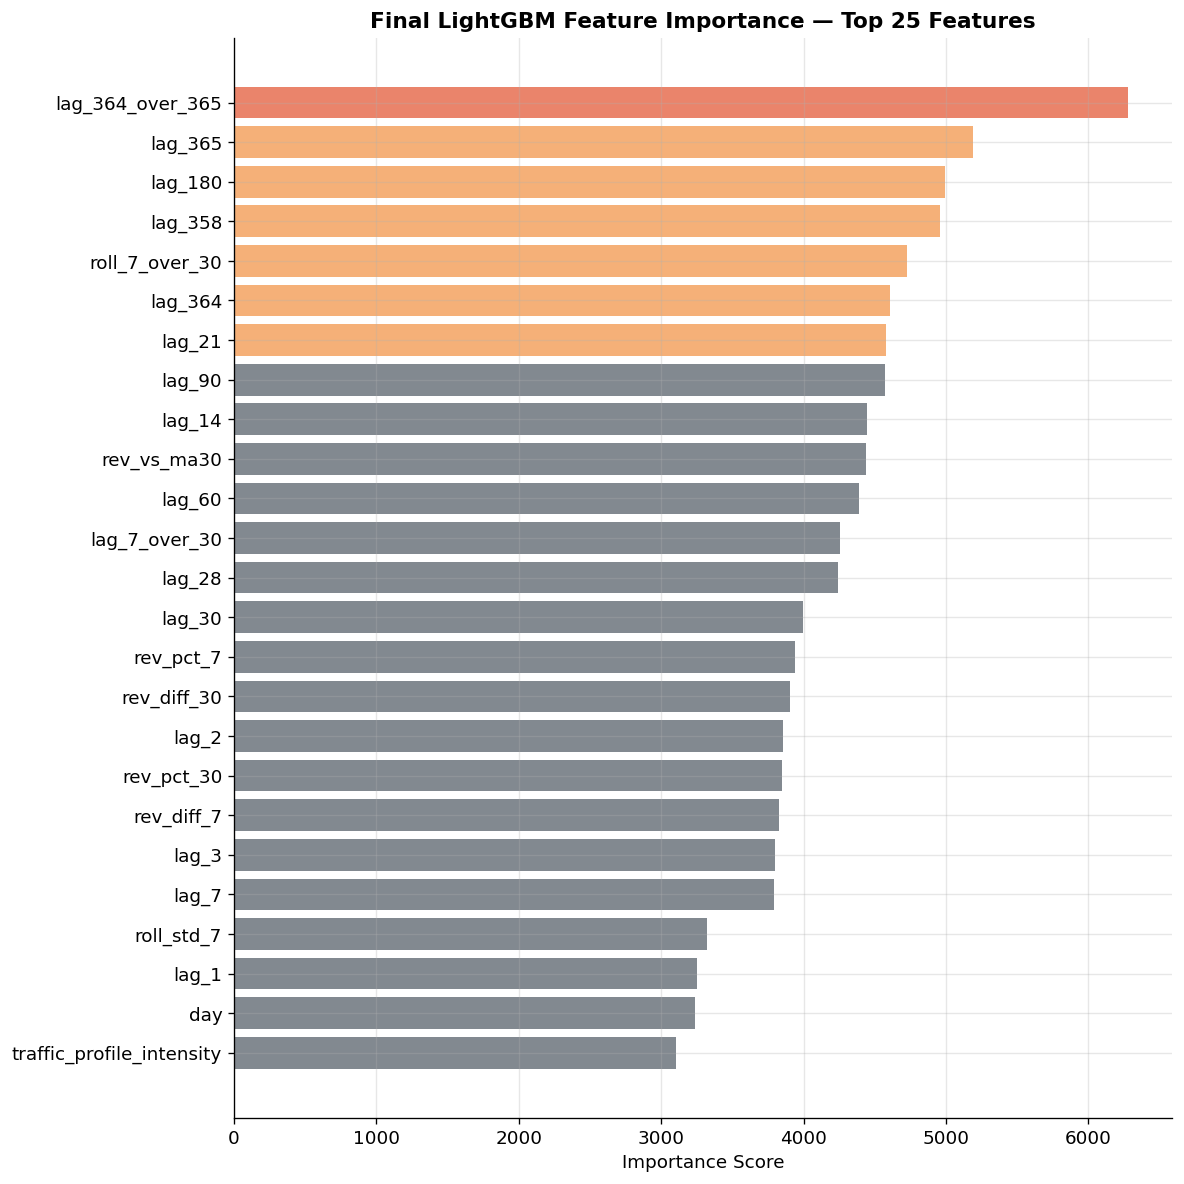

In [ ]:
fi_lgbm = pd.Series(final_lgbm.feature_importances_, index=feat_cols_full)
plot_feature_importance(fi_lgbm, "Final LightGBM Feature Importance", top_n=25)

### Business Interpretation

Phần này diễn giải kết quả explainability theo ngôn ngữ business.

Các nhóm tín hiệu thường quan trọng:

- Lag và rolling Revenue: doanh thu có tự tương quan mạnh.
- Calendar và mùa vụ: weekday, month, Tết, sale days.
- Promo/traffic/inventory profile: tín hiệu business phụ trợ, nhưng chỉ hữu ích nếu validation chứng minh có cải thiện.

Không nên kết luận feature tốt chỉ vì nghe hợp lý. Feature phải cải thiện validation sạch.


## Section 11 - Model Card

Model card là bản tóm tắt ngắn của pipeline cuối.

Nó ghi lại:

- Strategy được chọn.
- Số lượng feature.
- Validation MAE/RMSE/R2.
- Số dòng submission.

File nộp chính của notebook này là `../outputs/submission.csv`.


In [ ]:
if best_model_name == "ENS":
    strategy_summary = f"ENS_FIXED: LGBM({best_w_lgbm:.0%}) + XGB({best_w_xgb:.0%})"
    if has_catboost_best and best_w_catboost > 0:
        strategy_summary += f" + CAT({best_w_catboost:.0%})"
else:
    strategy_summary = f"{best_model_name} / {best_config_name}"
    if PROPHET_BLEND_WEIGHT > 0:
        strategy_summary += f" + Prophet({PROPHET_BLEND_WEIGHT:.0%})"
if USE_OPTUNA_CATBOOST and catboost_final_best_iter is not None and best_model_name == "CAT":
    strategy_summary += " + OptunaTunedCAT"

print_model_card(
    ensemble_summary=strategy_summary,
    n_features=len(feat_cols_full),
    cv_mae=best_selected_metrics["MAE"],
    cv_rmse=best_selected_metrics["RMSE"],
    cv_r2=best_selected_metrics["R2"],
    n_rows=len(sample_sub),
)
print("Primary submission: ../outputs/submission.csv")






╔══════════════════════════════════════════════════════════╗
║           GRIDBREAKERS — MODEL SUMMARY CARD             ║
╠══════════════════════════════════════════════════════════╣
║  Strategy    : CAT / D_full_pruned_v1 + Prophet(10%) + OptunaTunedCAT║
║  Features    : 119 engineered features                  ║
║  CV Strategy : 5-Fold TimeSeriesSplit (no random split)  ║
║  CV MAE      :      653,065 VNĐ                       ║
║  CV RMSE     :      935,234 VNĐ                       ║
║  CV R²       :        0.688                           ║
║  Random seed : 42 (all models)                           ║
║  Submission  : 548 rows (01/01/2023 → 01/07/2024)     ║
╚══════════════════════════════════════════════════════════╝
Primary submission: ../outputs/submission.csv


## Final Summary

Tóm tắt pipeline chính:

- Validation chọn config/model trên holdout 2022.
- Long-horizon backtest `548` ngày được dùng để tune framework weights.
- Model train trên log target.
- Forecast dùng recursive prediction với seasonal anchor được tune lại cho horizon dài.
- `Prophet` và `Optuna` chỉ còn là diagnostic tùy chọn, không nằm trong flow chính.
- File nộp cuối là `../outputs/submission.csv`.

Các hướng experimental như decomposition, robust rolling CV hoặc manual tilt nên để ở notebook riêng nếu cần phân tích thêm.

